In [4]:
"""!pip install numpy
!pip install networkx
!pip install matplotlib
!pip install pandas
!pip install tqdm
!pip install powerlaw"""

'!pip install numpy\n!pip install networkx\n!pip install matplotlib\n!pip install pandas\n!pip install tqdm\n!pip install powerlaw'

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import datetime
import networkx as nx
import pandas as pd

from utils_graphs import *

In [13]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/"

# Horas críticas identificadas en el artículo de Beiró and Gandica et al.
HORA_CRITICA_NAT = "429624"
HORA_CRITICA_9N = "437037"
HORA_CRITICA_CH = "394718"
HORA_CRITICA_WD = "422371"


In [6]:
hour_window_nat = 1
hour_window_9n = 2
hour_window_ch = 2
hour_window_wd = 6

In [7]:
limites = True

In [8]:
# CH
# Hashtags como nodos
if limites:
    lim_ch_und = int(210/hour_window_ch)
    lim_ch_sup = int(337/hour_window_ch)
else:
    lim_ch_und = None
    lim_ch_sup = None

# WD
# Hashtags como nodos
if limites:
    lim_wd_und = int(180/hour_window_wd)
    lim_wd_sup = None
else:
    lim_wd_und = None
    lim_wd_sup = None


In [7]:
def create_csv_weighted(input_file, output_file):
    df = pd.read_csv(input_file, sep= ',')

    df['weight'] = df.groupby(['user', 'hashtag', 'hour'])['user'].transform('count')
    result = df.drop_duplicates(subset=['user', 'hashtag', 'hour'])
    result.to_csv(output_file, sep=' ',index=False)

In [8]:
# create_csv_weighted(datasets_folder + "ch.csv", datasets_folder + "ch.txt")
# create_csv_weighted(datasets_folder + "wd.csv", datasets_folder + "wd.txt")


# Análisis Exploratorio de Datos (EDA) y creación de grafos

In [9]:
df_nat = read_data("nat", datasets_folder=datasets_folder)
df_9n = read_data("9n", datasets_folder=datasets_folder)
df_ch = read_data("ch", datasets_folder=datasets_folder)
df_wd = read_data("wd", datasets_folder=datasets_folder)


## Número de usuarios y hashtags únicos por hora

In [10]:
print("No al Tarifazo: número de usuarios únicos:", df_nat["user"].unique().shape[0], ", hashtags únicos:", df_nat["hashtag"].unique().shape[0], ", horas únicas:", df_nat["hour"].unique().shape[0], "en el conjunto de datos.\n")
print("9n: número de usuarios únicos:", df_9n["user"].unique().shape[0], ", hashtags únicos:", df_9n["hashtag"].unique().shape[0], ", horas únicas::", df_9n["hour"].unique().shape[0], "en el conjunto de datos.\n")

print("Charlie Hebdo: número de usuarios únicos:", df_ch["user"].unique().shape[0], ", hashtags únicos:", df_ch["hashtag"].unique().shape[0], ", horas únicas:", df_ch["hour"].unique().shape[0], "en el conjunto de datos.\n")
print("Womanday: número de usuarios únicos:", df_wd["user"].unique().shape[0], ", hashtags únicos:", df_wd["hashtag"].unique().shape[0], ", horas únicas:", df_wd["hour"].unique().shape[0], "en el conjunto de datos.\n")

No al Tarifazo: número de usuarios únicos: 9670 , hashtags únicos: 23398 , horas únicas: 260 en el conjunto de datos.

9n: número de usuarios únicos: 8022 , hashtags únicos: 18717 , horas únicas:: 97 en el conjunto de datos.

Charlie Hebdo: número de usuarios únicos: 16146 , hashtags únicos: 37598 , horas únicas: 504 en el conjunto de datos.

Womanday: número de usuarios únicos: 2319 , hashtags únicos: 10074 , horas únicas: 283 en el conjunto de datos.



In [11]:

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]
hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]
hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]
hour_wd = np.sort(df_wd["hour"].unique())[::hour_window_wd]


# Ajusto la ventana a la que pertence la hora critica de WD
HORA_CRITICA_9N = str(int(HORA_CRITICA_9N) - (int(HORA_CRITICA_9N)-int(hour_9n[0]))%hour_window_9n)
HORA_CRITICA_NAT = str(int(HORA_CRITICA_NAT) - (int(HORA_CRITICA_NAT)-int(hour_nat[0]))%hour_window_nat)
HORA_CRITICA_CH = str(int(HORA_CRITICA_CH) - (int(HORA_CRITICA_CH)-int(hour_ch[0]))%hour_window_ch)
HORA_CRITICA_WD = str(int(HORA_CRITICA_WD) - (int(HORA_CRITICA_WD)-int(hour_wd[0]))%hour_window_wd)

In [12]:
print("La nueva hora crítica 9N es:", HORA_CRITICA_9N)
print("La nueva hora crítica NAT es:", HORA_CRITICA_NAT)
print("La nueva hora crítica CH es:", HORA_CRITICA_CH)
print("La nueva hora crítica WD es:", HORA_CRITICA_WD)

La nueva hora crítica 9N es: 437037
La nueva hora crítica NAT es: 429624
La nueva hora crítica CH es: 394717
La nueva hora crítica WD es: 422369


In [13]:
# Añado el numero de usuarios y hashtags únicos a sendos arrays

num_user_nat = []
num_hashtag_nat = []
for hour in np.sort(df_nat["hour"].unique())[::hour_window_nat]:
    conditions = (df_nat["hour"] == hour)
    for step in range(1, hour_window_nat):
        conditions |= (df_nat["hour"]  == hour + step)
    df_hour_nat = df_nat[conditions] 
    num_user_nat.append(len(df_hour_nat["user"].unique()))
    num_hashtag_nat.append(len(df_hour_nat["hashtag"].unique()))


num_user_9n = []
num_hashtag_9n = []
for hour in np.sort(df_9n["hour"].unique())[::hour_window_9n]:
    conditions = (df_9n["hour"] == hour)
    for step in range(1, hour_window_9n):
        conditions |= (df_9n["hour"]  == hour + step)
    df_hour_9n = df_9n[conditions] 
    num_user_9n.append(len(df_hour_9n["user"].unique()))
    num_hashtag_9n.append(len(df_hour_9n["hashtag"].unique()))

num_user_ch = []
num_hashtag_ch = []
for hour in np.sort(df_ch["hour"].unique())[::hour_window_ch]:
    conditions = (df_ch["hour"] == hour)
    for step in range(1, hour_window_ch):
        conditions |= (df_ch["hour"]  == hour + step)
    df_hour_ch = df_ch[conditions] 
    num_user_ch.append(len(df_hour_ch["user"].unique()))
    num_hashtag_ch.append(len(df_hour_ch["hashtag"].unique()))

num_user_wd = []
num_hashtag_wd = []
for hour in np.sort(df_wd["hour"].unique())[::hour_window_wd]:
    conditions = (df_wd["hour"] == hour)
    for step in range(1, hour_window_wd):
        conditions |= (df_wd["hour"]  == hour + step)
    df_hour_wd = df_wd[conditions] 
    num_user_wd.append(len(df_hour_wd["user"].unique()))
    num_hashtag_wd.append(len(df_hour_wd["hashtag"].unique()))

In [14]:
# Convierto la hora a formato año, mes, día, hora
hour_nat_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_nat]
hour_9n_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_9n]
hour_ch_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_ch]
hour_wd_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_wd]

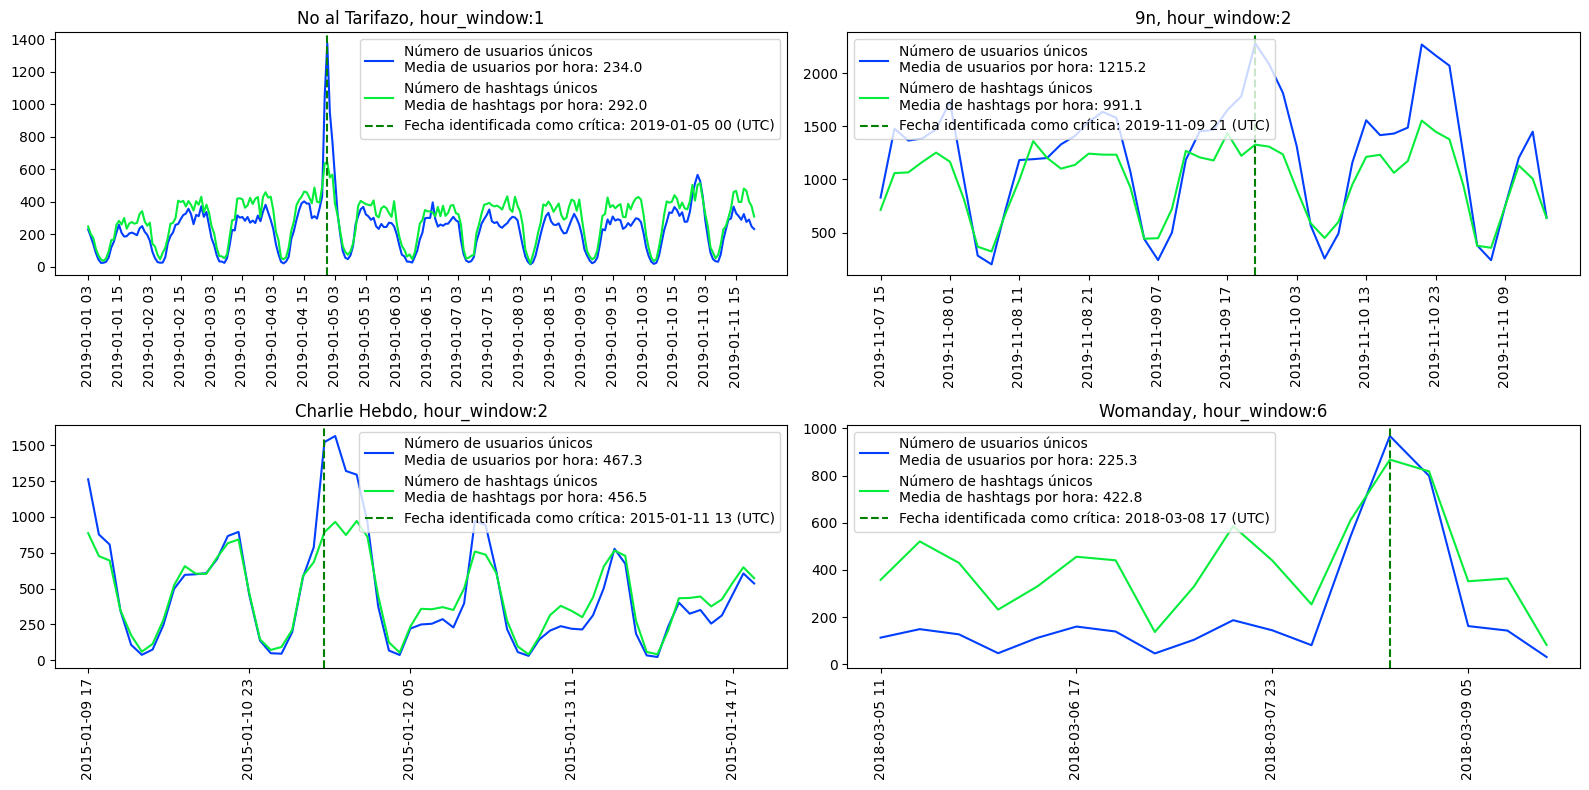

In [15]:
plt.style.use('seaborn-v0_8-bright')    

fig, axs = plt.subplots(2, 2)
axs = axs.flat
fig.set_size_inches(16,8)

for ax in axs:  # axs es una matriz, hay que aplanarla con .flat
    ax.set_facecolor("white")

axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))
axs[0].plot(hour_nat_dt, num_user_nat, label="Número de usuarios únicos\nMedia de usuarios por hora: " +str(round(np.mean(num_user_nat), 1)))
axs[0].plot(hour_nat_dt, num_hashtag_nat, label="Número de hashtags únicos\nMedia de hashtags por hora: " +str(round(np.mean(num_hashtag_nat), 1)))
# Marcamos la hora marcada como crítica en Beiró & Gandica et al.
axs[0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')
axs[0].set_xticks(hour_nat_dt[::12])
axs[0].set_xticklabels(hour_nat_dt[::12])
axs[0].tick_params(axis='x', rotation=90)
axs[0].legend()

axs[1].set_title("9n, hour_window:" + str(hour_window_9n))
axs[1].plot(hour_9n_dt, num_user_9n, label="Número de usuarios únicos\nMedia de usuarios por hora: " +str(round(np.mean(num_user_9n), 1)))
axs[1].plot(hour_9n_dt, num_hashtag_9n, label="Número de hashtags únicos\nMedia de hashtags por hora: " +str(round(np.mean(num_hashtag_9n), 1)))
# Marcamos la hora marcada como crítica en Beiró & Gandica et al.
axs[1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')
axs[1].set_xticks(hour_9n_dt[::5])
axs[1].set_xticklabels(hour_9n_dt[::5])
axs[1].tick_params(axis='x', rotation=90)
axs[1].legend()

axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch))
axs[2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], num_user_ch[lim_ch_und:lim_ch_sup], label="Número de usuarios únicos\nMedia de usuarios por hora: " +str(round(np.mean(num_user_ch[lim_ch_und:lim_ch_sup]), 1)))
axs[2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], num_hashtag_ch[lim_ch_und:lim_ch_sup], label="Número de hashtags únicos\nMedia de hashtags por hora: " +str(round(np.mean(num_hashtag_ch[lim_ch_und:lim_ch_sup]), 1)))
# Marcamos la hora marcada como crítica en Beiró & Gandica et al.
axs[2].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')
axs[2].set_xticks(hour_ch_dt[lim_ch_und:lim_ch_sup:15])
axs[2].set_xticklabels(hour_ch_dt[lim_ch_und:lim_ch_sup:15])
axs[2].tick_params(axis='x', rotation=90)
axs[2].legend()

axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd))
axs[3].plot(hour_wd_dt[lim_wd_und:lim_wd_sup], num_user_wd[lim_wd_und:lim_wd_sup], label="Número de usuarios únicos\nMedia de usuarios por hora: " +str(round(np.mean(num_user_wd[lim_wd_und:lim_wd_sup]), 1)))
axs[3].plot(hour_wd_dt[lim_wd_und:lim_wd_sup], num_hashtag_wd[lim_wd_und:lim_wd_sup], label="Número de hashtags únicos\nMedia de hashtags por hora: " +str(round(np.mean(num_hashtag_wd[lim_wd_und:lim_wd_sup]), 1)))
# Marcamos la hora marcada como crítica en Beiró & Gandica et al.
axs[3].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_WD)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_WD)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')
axs[3].set_xticks(hour_wd_dt[lim_wd_und:lim_wd_sup:5])
axs[3].set_xticklabels(hour_wd_dt[lim_wd_und:lim_wd_sup:5])
axs[3].tick_params(axis='x', rotation=90)
axs[3].legend()

plt.tight_layout()
plt.savefig(plots_folder + "num_unique_users_hashtags_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()


## Creación de redes por hora

In [16]:
"""# Creamos grafos de la manifestación del 9n
manifestacion = "9n"

create_graphs("hashtag", "user", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)

create_graphs("user", "hashtag", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)

create_bipartite_graph(df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)"""

"""#Creamos grafos de la manifestación del No al Tarifazo
manifestacion = "nat"

create_graphs("hashtag", "user", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)

create_graphs("user", "hashtag", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)

create_bipartite_graph(df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)"""

"""# Creamos grafos de la manifestación de Charlie HEbdo
manifestacion = "ch"

create_graphs("hashtag", "user", df_ch, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_ch)

create_graphs("user", "hashtag", df_ch, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_ch)

create_bipartite_graph(df_ch, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_ch)"""

"""# Creamos grafos de la manifestación de Womanday
manifestacion = "wd"

create_graphs("hashtag", "user", df_wd, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_wd)

create_graphs("user", "hashtag", df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)

create_bipartite_graph(df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)"""

'# Creamos grafos de la manifestación de Womanday\nmanifestacion = "wd"\n\ncreate_graphs("hashtag", "user", df_wd, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_wd)\n\ncreate_graphs("user", "hashtag", df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)\n\ncreate_bipartite_graph(df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)'

## Número  de nodos y aristas en los grafos generados por hora

In [17]:
# Se leen los grafos creados para cada hora y se almacena el número de nodos y de aristas de cada uno
num_edges_nat = []
num_nodes_nat = []
for hour in tqdm(hour_nat):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/nat/" + str(hour_window_nat) + '/' + str(hour) + '.gexf')
    num_edges_nat.append(G.number_of_edges())
    num_nodes_nat.append(G.number_of_nodes())

num_edges_9n = []
num_nodes_9n = []
for hour in tqdm(hour_9n):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/9n/" + str(hour_window_9n) + '/' + str(hour) + '.gexf')
    num_edges_9n.append(G.number_of_edges())
    num_nodes_9n.append(G.number_of_nodes())

num_edges_ch = []
num_nodes_ch = []
for hour in tqdm(hour_ch):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/ch/" + str(hour_window_ch) + '/' + str(hour) + '.gexf')
    num_edges_ch.append(G.number_of_edges())
    num_nodes_ch.append(G.number_of_nodes())

num_edges_wd = []
num_nodes_wd = []
for hour in tqdm(hour_wd):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/wd/" + str(hour_window_wd) + '/' + str(hour) + '.gexf')
    num_edges_wd.append(G.number_of_edges())
    num_nodes_wd.append(G.number_of_nodes())

100%|██████████| 48/48 [00:01<00:00, 42.98it/s]


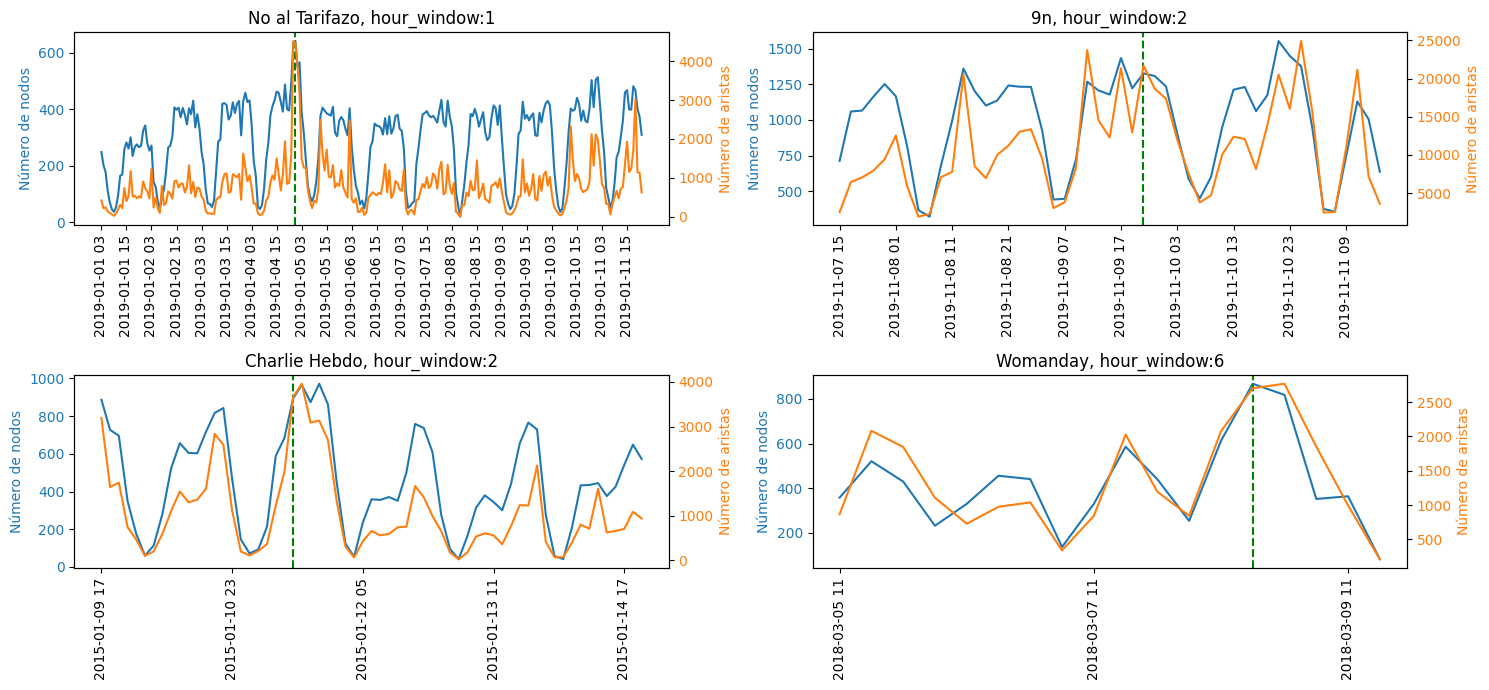

In [18]:
plt.style.use('seaborn-v0_8-bright')    

fig, axs = plt.subplots(2, 2, figsize=(15, 7))
axs = axs.flat
for ax in axs:
    ax.set_facecolor("white")

axs[0].plot(hour_nat_dt, num_nodes_nat, '#1f77b4', label="Número de nodos\nMedia de nodos por hora: " +str(round(np.mean(num_nodes_nat), 1)))
axs[0].set_ylabel('Número de nodos', color='#1f77b4')
axs[0].tick_params(axis='y', labelcolor='#1f77b4')
# Marcamos la hora marcada como crítica en Beiró & Yérali et al.
axs[0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")))

ax1b = axs[0].twinx()
ax1b.plot(hour_nat_dt, num_edges_nat, '#ff7f0e', label="Número de aristas \nMedia de aristas por hora: " +str(round(np.mean(num_edges_nat), 1)))
ax1b.set_ylabel('Número de aristas', color='#ff7f0e')
ax1b.tick_params(axis='y', labelcolor='#ff7f0e')
axs[0].set_title('No al Tarifazo, hour_window:' + str(hour_window_nat))
axs[0].set_xticks(hour_nat_dt[::12])
axs[0].set_xticklabels(hour_nat_dt[::12])
axs[0].tick_params(axis='x', rotation=90)

axs[1].plot(hour_9n_dt, num_nodes_9n, '#1f77b4', label="Número de nodos\nMedia de nodos por hora: " +str(round(np.mean(num_nodes_9n), 1)))
axs[1].set_ylabel('Número de nodos', color='#1f77b4')
axs[1].tick_params(axis='y', labelcolor='#1f77b4')
# Marcamos la hora marcada como crítica en Beiró & Yérali et al.
axs[1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")))

ax2b = axs[1].twinx()
ax2b.plot(hour_9n_dt, num_edges_9n, '#ff7f0e', label="Número de aristas\nMedia de aristas por hora: " +str(round(np.mean(num_edges_9n), 1)))
ax2b.set_ylabel('Número de aristas', color='#ff7f0e')
ax2b.tick_params(axis='y', labelcolor='#ff7f0e')
axs[1].set_title('9n, hour_window:' + str(hour_window_9n))

axs[1].set_xticks(hour_9n_dt[::5])
axs[1].set_xticklabels(hour_9n_dt[::5])
axs[1].tick_params(axis='x', rotation=90)

axs[2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], num_nodes_ch[lim_ch_und:lim_ch_sup], '#1f77b4', label="Número de nodos\nMedia de nodos por hora: " +str(round(np.mean(num_nodes_ch[lim_ch_und:lim_ch_sup]), 1)))
axs[2].set_ylabel('Número de nodos', color='#1f77b4')
axs[2].tick_params(axis='y', labelcolor='#1f77b4')
# Marcamos la hora marcada como crítica en Beiró & Yérali et al.
axs[2].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")))

ax3b = axs[2].twinx()
ax3b.plot(hour_ch_dt[lim_ch_und:lim_ch_sup], num_edges_ch[lim_ch_und:lim_ch_sup], '#ff7f0e', label="Número de aristas\nMedia de aristas por hora: " +str(round(np.mean(num_edges_ch[lim_ch_und:lim_ch_sup]), 1)))
ax3b.set_ylabel('Número de aristas', color='#ff7f0e')
ax3b.tick_params(axis='y', labelcolor='#ff7f0e')
axs[2].set_title('Charlie Hebdo, hour_window:' + str(hour_window_ch))

axs[2].set_xticks(hour_ch_dt[lim_ch_und:lim_ch_sup:15])
axs[2].set_xticklabels(hour_ch_dt[lim_ch_und:lim_ch_sup:15])
axs[2].tick_params(axis='x', rotation=90)

axs[3].plot(hour_wd_dt[lim_wd_und:lim_wd_sup], num_nodes_wd[lim_wd_und:lim_wd_sup], '#1f77b4', label="Número de nodos\nMedia de nodos por hora: " +str(round(np.mean(num_nodes_wd[lim_wd_und:lim_wd_sup]), 1)))
axs[3].set_ylabel('Número de nodos', color='#1f77b4')
axs[3].tick_params(axis='y', labelcolor='#1f77b4')
# Marcamos la hora marcada como crítica en Beiró & Yérali et al.
axs[3].axvline(x=datetime.datetime.fromtimestamp((int(HORA_CRITICA_WD))*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")))

ax3b = axs[3].twinx()
ax3b.plot(hour_wd_dt[lim_wd_und:lim_wd_sup], num_edges_wd[lim_wd_und:lim_wd_sup], '#ff7f0e', label="Número de aristas\nMedia de aristas por hora: " +str(round(np.mean(num_edges_wd[lim_wd_und:lim_wd_sup]), 1)))
ax3b.set_ylabel('Número de aristas', color='#ff7f0e')
ax3b.tick_params(axis='y', labelcolor='#ff7f0e')
axs[3].set_title('Womanday, hour_window:' + str(hour_window_wd))

axs[3].set_xticks(hour_wd_dt[lim_wd_und:lim_wd_sup:8])
axs[3].set_xticklabels(hour_wd_dt[lim_wd_und:lim_wd_sup:8])
axs[3].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(plots_folder + "num_nodes_edges_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

## Coeficiente de anidamiento y modularidad por ventana horaria

In [19]:
print("9n")
# Manifestación: 9n
# Hashtags como nodos
hour_sort_9n_h, mod_sort_9n_h, nest_sort_9n_h = get_clust_nest_coefficient("9n", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)

# Usuarios como nodos
hour_sort_9n_u, mod_sort_9n_u, nest_sort_9n_u = get_clust_nest_coefficient("9n", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)

# Redes bipartitas
hour_sort_9n_b, mod_sort_9n_b, nest_sort_9n_b = get_clust_nest_coefficient("9n", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)


print("No al Tarifazo")
# Manifestación: No al Tarifazo
# Hashtags como nodos
hour_sort_nat_h, mod_sort_nat_h, nest_sort_nat_h = get_clust_nest_coefficient("nat", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)

# Usuarios como nodos
hour_sort_nat_u, mod_sort_nat_u, nest_sort_nat_u = get_clust_nest_coefficient("nat", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)

# Redes bipartitas
hour_sort_nat_b, mod_sort_nat_b, nest_sort_nat_b = get_clust_nest_coefficient("nat", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)


print("Charlie Hebdo")
# Manifestación: Charlie Hebdo
# Hashtags como nodos
hour_sort_ch_h, mod_sort_ch_h, nest_sort_ch_h = get_clust_nest_coefficient("ch", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)

# Usuarios como nodos
hour_sort_ch_u, mod_sort_ch_u, nest_sort_ch_u = get_clust_nest_coefficient("ch", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)

# Redes bipartitas
hour_sort_ch_b, mod_sort_ch_b, nest_sort_ch_b = get_clust_nest_coefficient("ch", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)


print("WomanDay")
# Manifestación: WomanDay
# Hashtags como nodos
hour_sort_wd_h, mod_sort_wd_h, nest_sort_wd_h = get_clust_nest_coefficient("wd", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)

# Usuarios como nodos
hour_sort_wd_u, mod_sort_wd_u, nest_sort_wd_u = get_clust_nest_coefficient("wd", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)

# Redes bipartitas
hour_sort_wd_b, mod_sort_wd_b, nest_sort_wd_b = get_clust_nest_coefficient("wd", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)

9n
Calculando el anidamiento y modularidad de 9n con criterio: h


100%|██████████| 49/49 [00:00<00:00, 225105.03it/s]

Calculando el anidamiento y modularidad de 9n con criterio: u



100%|██████████| 49/49 [00:00<00:00, 246723.76it/s]


Calculando el anidamiento y modularidad de 9n con criterio: b


...

100%|██████████| 48/48 [00:00<00:00, 413401.63it/s]


Calculando el anidamiento y modularidad de wd con criterio: u


100%|██████████| 48/48 [00:00<00:00, 418558.40it/s]


Calculando el anidamiento y modularidad de wd con criterio: b


100%|██████████| 48/48 [00:00<00:00, 399457.52it/s]


In [20]:
# Convertimos el formato horario para el gráfico
dt_sort_arr_nat=[]
for hour in hour_sort_nat_h:
    dt_sort_arr_nat.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"))

dt_sort_arr_9n=[]
for hour in hour_sort_9n_b:
    dt_sort_arr_9n.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"))

dt_sort_arr_ch=[]
for hour in hour_sort_ch_b:
    dt_sort_arr_ch.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"))

dt_sort_arr_wd=[]
for hour in hour_sort_wd_b:
    dt_sort_arr_wd.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"))

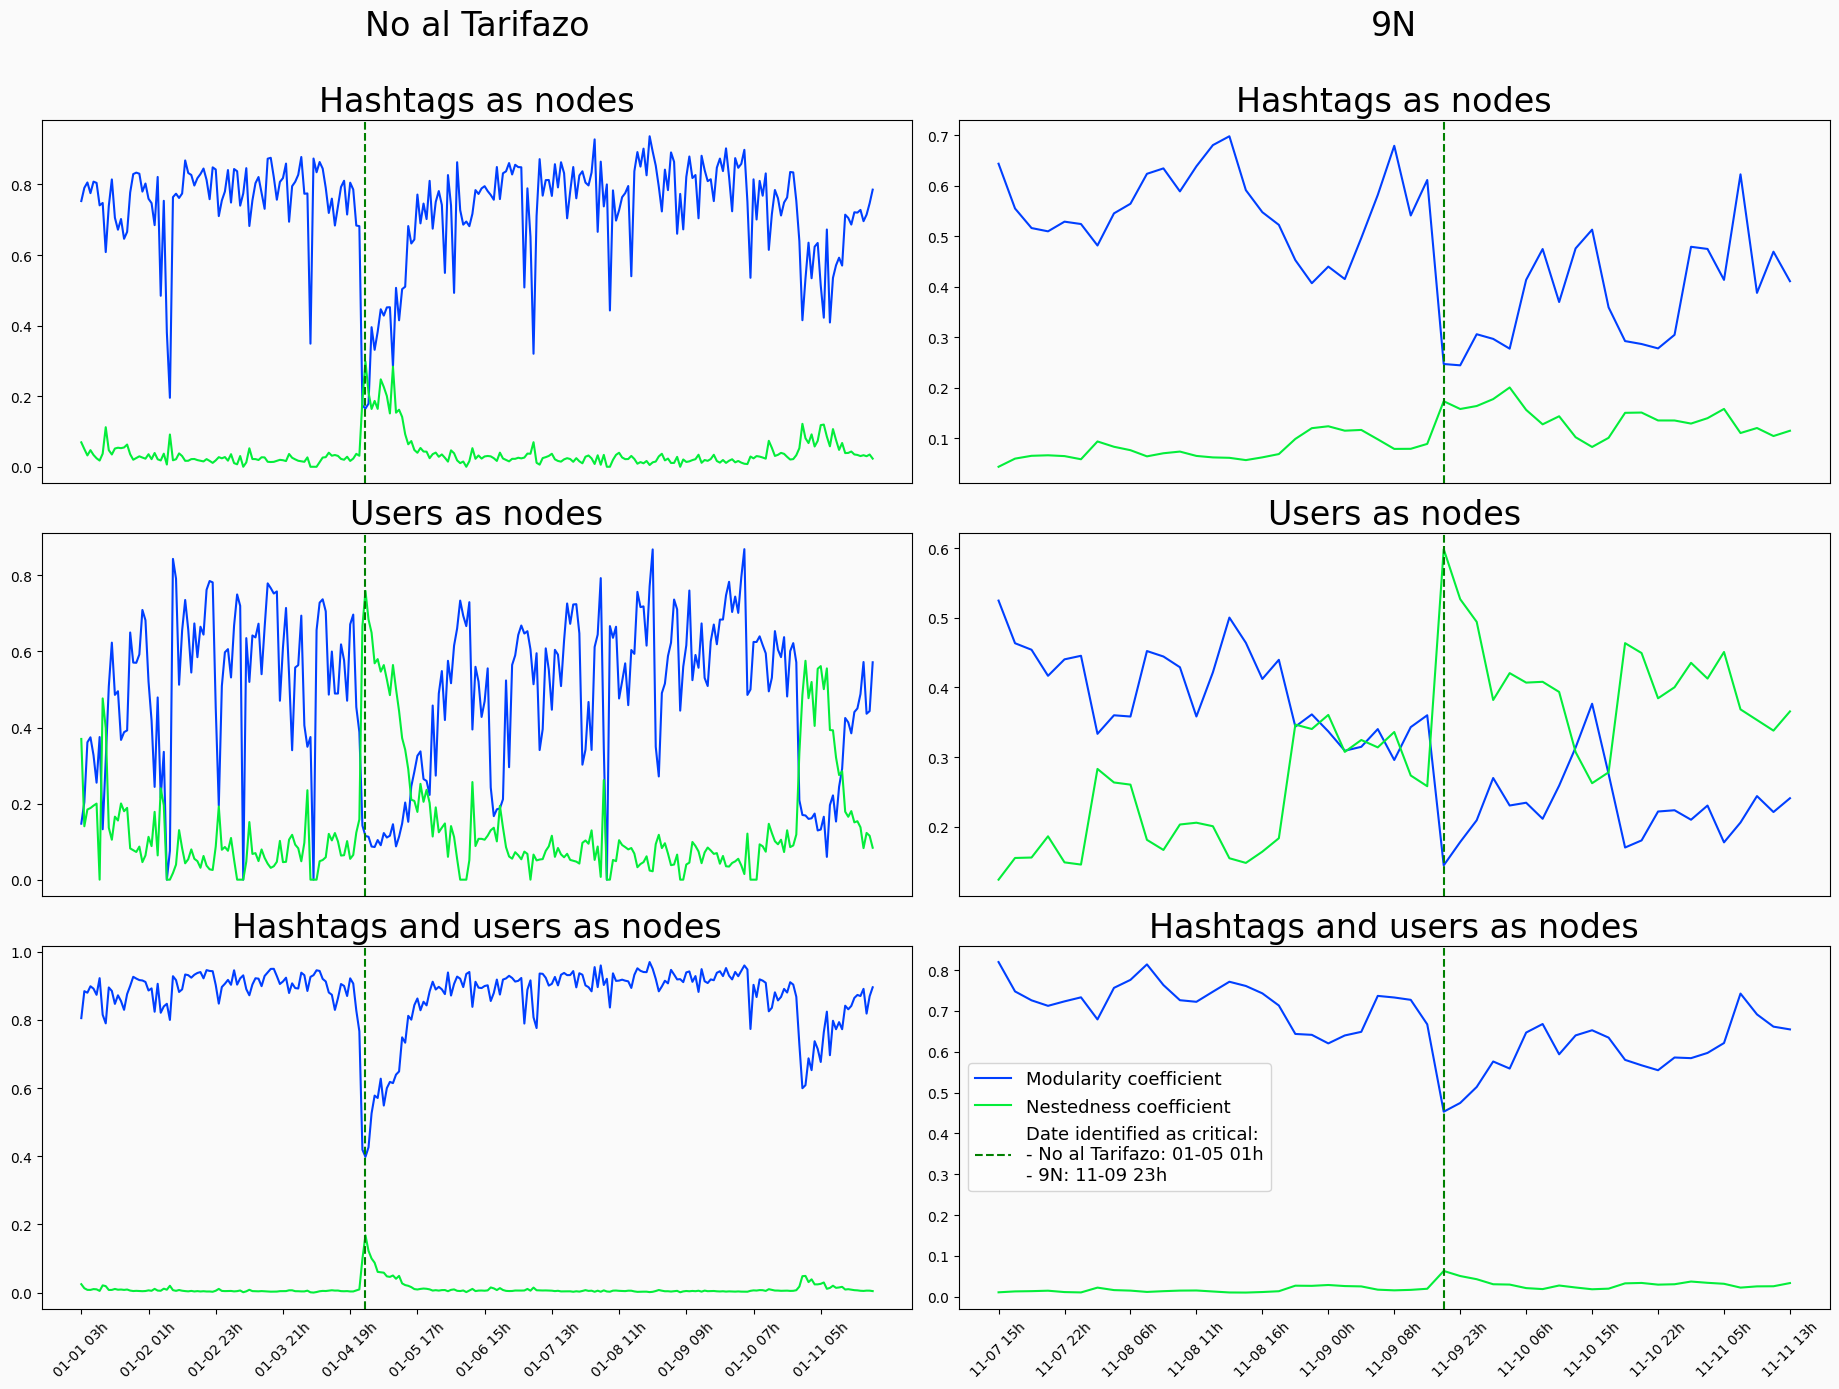

In [21]:
plt.style.use('seaborn-v0_8-bright')

fig, axs = plt.subplots(3, 2, facecolor="#fafafa")
fig.set_size_inches(18.5,14)

for ax in axs.flat:  
    ax.set_facecolor("#fafafa")
    #ax.set_ylim(0,1)
# No al Tarifazo
# Hashtags como nodos

axs[0, 0].plot(dt_sort_arr_nat, mod_sort_nat_h)
axs[0, 0].plot(dt_sort_arr_nat, nest_sort_nat_h)
axs[0, 0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"), color="green", ls="--")
axs[0, 0].get_xaxis().set_visible(False)
axs[0, 0].set_title("No al Tarifazo\n\nHashtags as nodes", fontsize=24)

# Usuarios como nodos
axs[1, 0].plot(dt_sort_arr_nat, mod_sort_nat_u)
axs[1, 0].plot(dt_sort_arr_nat, nest_sort_nat_u)
axs[1, 0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"), color="green", ls="--")
axs[1, 0].get_xaxis().set_visible(False)
axs[1, 0].set_title("Users as nodes", fontsize=24)

# Redes bipartitas
axs[2, 0].plot(dt_sort_arr_nat, mod_sort_nat_b)
axs[2, 0].plot(dt_sort_arr_nat, nest_sort_nat_b)
axs[2, 0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"), color="green", ls="--")
axs[2, 0].set_xticks(dt_sort_arr_nat[::22])
axs[2, 0].set_xticklabels(dt_sort_arr_nat[::22])
axs[2, 0].tick_params(axis='x', rotation=45)
axs[2, 0].grid(axis='x', linestyle='')
axs[2, 0].set_title("Hashtags and users as nodes", fontsize=24)

# 9n
# Hashtags como nodos
HORA_CRITICA_9N = "437038"

axs[0, 1].plot(dt_sort_arr_9n, mod_sort_9n_h)
axs[0, 1].plot(dt_sort_arr_9n, nest_sort_9n_h)
axs[0, 1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"), color="green", ls="--")
axs[0, 1].get_xaxis().set_visible(False)
axs[0, 1].set_title("9N\n\nHashtags as nodes", fontsize=24)
#axs[0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')

# Usuarios como nodos
axs[1, 1].plot(dt_sort_arr_9n, mod_sort_9n_u)
axs[1, 1].plot(dt_sort_arr_9n, nest_sort_9n_u)
axs[1, 1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"), color="green", ls="--")
axs[1, 1].get_xaxis().set_visible(False)
axs[1, 1].set_title("Users as nodes", fontsize=24)

# Redes bipartitas
axs[2, 1].plot(dt_sort_arr_9n, mod_sort_9n_b, label = "Modularity coefficient")
axs[2, 1].plot(dt_sort_arr_9n, nest_sort_9n_b, label = "Nestedness coefficient")
axs[2, 1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"), color="green", ls="--", label="Date identified as critical:\n- No al Tarifazo: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600).strftime("%m-%d %Hh")) + "\n- 9N: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600).strftime("%m-%d %Hh")))
axs[2, 1].set_xticks(dt_sort_arr_9n[::4])
axs[2, 1].set_xticklabels(dt_sort_arr_9n[::4])
axs[2, 1].grid(axis='x', linestyle='')
axs[2, 1].tick_params(axis='x', rotation=45)
axs[2, 1].legend(loc = "center left", fontsize=13)
axs[2, 1].set_title("Hashtags and users as nodes", fontsize=24)


plt.tight_layout()
#fig.suptitle('Coeficientes de modularidad y de anidamiento para diferentes formaciones de las redes de conectividad', y=1.05)
plt.savefig(plots_folder + "mod_nest_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + ".png")
plt.show()
HORA_CRITICA_9N = "437037"


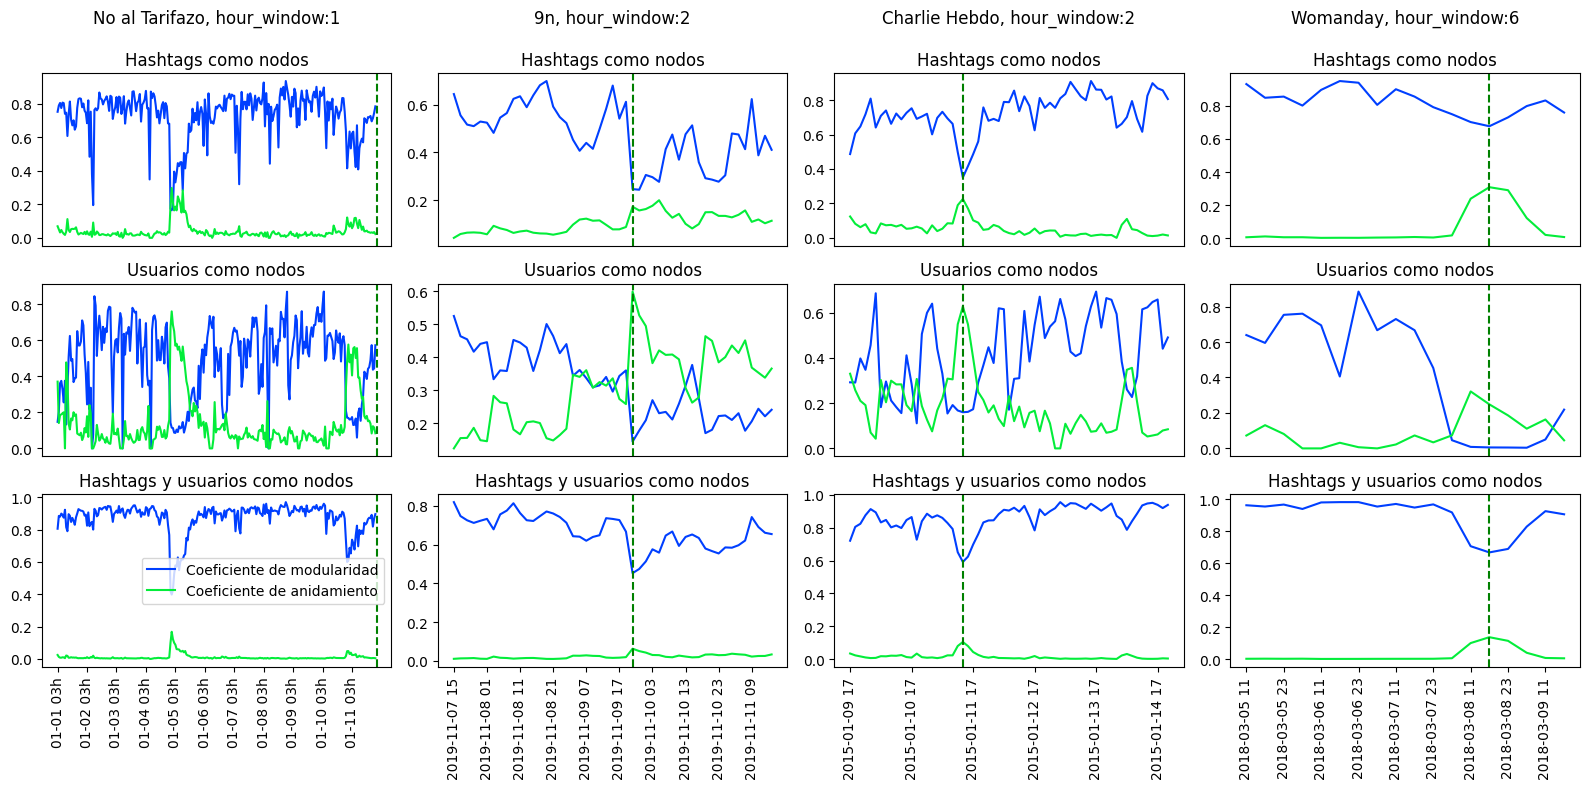

In [22]:
plt.style.use('seaborn-v0_8-bright')

fig, axs = plt.subplots(3, 4)
fig.set_size_inches(16,8)

for ax in axs.flat:  
    ax.set_facecolor("white")
# No al Tarifazo
# Hashtags como nodos

axs[0, 0].plot(dt_sort_arr_nat, mod_sort_nat_h)
axs[0, 0].plot(dt_sort_arr_nat, nest_sort_nat_h)
axs[0, 0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[0, 0].get_xaxis().set_visible(False)
axs[0, 0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat) + "\n\nHashtags como nodos")

# Usuarios como nodos
axs[1, 0].plot(dt_sort_arr_nat, mod_sort_nat_u)
axs[1, 0].plot(dt_sort_arr_nat, nest_sort_nat_u)
axs[1, 0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[1, 0].get_xaxis().set_visible(False)
axs[1, 0].set_title("Usuarios como nodos")

# Redes bipartitas
axs[2, 0].plot(dt_sort_arr_nat, mod_sort_nat_b, label = "Coeficiente de modularidad")
axs[2, 0].plot(dt_sort_arr_nat, nest_sort_nat_b, label = "Coeficiente de anidamiento")
axs[2, 0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[2, 0].set_xticks(dt_sort_arr_nat[::24])
axs[2, 0].set_xticklabels(dt_sort_arr_nat[::24])
axs[2, 0].tick_params(axis='x', rotation=90)
axs[2, 0].grid(axis='x', linestyle='')
axs[2, 0].legend(loc = "center right")
axs[2, 0].set_title("Hashtags y usuarios como nodos")

# 9n
# Hashtags como nodos

axs[0, 1].plot(hour_9n_dt, mod_sort_9n_h)
axs[0, 1].plot(hour_9n_dt, nest_sort_9n_h)
axs[0, 1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[0, 1].get_xaxis().set_visible(False)
axs[0, 1].set_title("9n, hour_window:" + str(hour_window_9n) + "\n\nHashtags como nodos")

# Usuarios como nodos
axs[1, 1].plot(hour_9n_dt, mod_sort_9n_u)
axs[1, 1].plot(hour_9n_dt, nest_sort_9n_u)
axs[1, 1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[1, 1].get_xaxis().set_visible(False)
axs[1, 1].set_title("Usuarios como nodos")

# Redes bipartitas
axs[2, 1].plot(hour_9n_dt, mod_sort_9n_b)
axs[2, 1].plot(hour_9n_dt, nest_sort_9n_b)
axs[2, 1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[2, 1].set_xticks(hour_9n_dt[::5])
axs[2, 1].set_xticklabels(hour_9n_dt[::5])
axs[2, 1].grid(axis='x', linestyle='')
axs[2, 1].tick_params(axis='x', rotation=90)
axs[2, 1].set_title("Hashtags y usuarios como nodos")


axs[0, 2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], mod_sort_ch_h[lim_ch_und:lim_ch_sup])
axs[0, 2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], nest_sort_ch_h[lim_ch_und:lim_ch_sup])
axs[0, 2].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[0, 2].get_xaxis().set_visible(False)
axs[0, 2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch) + "\n\nHashtags como nodos")

# Usuarios como nodos
axs[1, 2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], mod_sort_ch_u[lim_ch_und:lim_ch_sup])
axs[1, 2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], nest_sort_ch_u[lim_ch_und:lim_ch_sup])
axs[1, 2].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[1, 2].get_xaxis().set_visible(False)
axs[1, 2].set_title("Usuarios como nodos")

# Redes bipartitas
axs[2, 2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], mod_sort_ch_b[lim_ch_und:lim_ch_sup])
axs[2, 2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], nest_sort_ch_b[lim_ch_und:lim_ch_sup])
axs[2, 2].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[2, 2].set_xticks(hour_ch_dt[lim_ch_und:lim_ch_sup:12])
axs[2, 2].set_xticklabels(hour_ch_dt[lim_ch_und:lim_ch_sup:12])
axs[2, 2].grid(axis='x', linestyle='')
axs[2, 2].tick_params(axis='x', rotation=90)
axs[2, 2].set_title("Hashtags y usuarios como nodos")



axs[0, 3].plot(dt_sort_arr_wd[lim_wd_und:lim_wd_sup], mod_sort_wd_h[lim_wd_und:lim_wd_sup])
axs[0, 3].plot(dt_sort_arr_wd[lim_wd_und:lim_wd_sup], nest_sort_wd_h[lim_wd_und:lim_wd_sup])
axs[0, 3].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_WD)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[0, 3].get_xaxis().set_visible(False)
axs[0, 3].set_title("Womanday, hour_window:" + str(hour_window_wd) + "\n\nHashtags como nodos")

# Usuarios como nodos
axs[1, 3].plot(dt_sort_arr_wd[lim_wd_und:lim_wd_sup], mod_sort_wd_u[lim_wd_und:lim_wd_sup])
axs[1, 3].plot(dt_sort_arr_wd[lim_wd_und:lim_wd_sup], nest_sort_wd_u[lim_wd_und:lim_wd_sup])
axs[1, 3].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_WD)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[1, 3].get_xaxis().set_visible(False)
axs[1, 3].set_title("Usuarios como nodos")

# Redes bipartitas
axs[2, 3].plot(dt_sort_arr_wd[lim_wd_und:lim_wd_sup], mod_sort_wd_b[lim_wd_und:lim_wd_sup])
axs[2, 3].plot(dt_sort_arr_wd[lim_wd_und:lim_wd_sup], nest_sort_wd_b[lim_wd_und:lim_wd_sup])
axs[2, 3].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_WD)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[2, 3].set_xticks(dt_sort_arr_wd[lim_wd_und:lim_wd_sup:2])
axs[2, 3].set_xticklabels(dt_sort_arr_wd[lim_wd_und:lim_wd_sup:2])
axs[2, 3].grid(axis='x', linestyle='')
axs[2, 3].tick_params(axis='x', rotation=90)
axs[2, 3].set_title("Hashtags y usuarios como nodos")

plt.tight_layout()
#fig.suptitle('Coeficientes de modularidad y de anidamiento para diferentes formaciones de las redes de conectividad', y=1.05)
plt.savefig(plots_folder + "mod_nest_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

## Función de Distribución de Probabilidad (PDF) y Función de Distribución Cumulativa Complementaria (CCDF) de las horas críticas

In [23]:
#No al Tarifazo
plfit_nat, arr_pdf_points_nat, arr_ccdf_points_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, read=False)

# 9n
plfit_9n, arr_pdf_points_9n, arr_ccdf_points_9n = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)

# ch
plfit_ch, arr_pdf_points_ch, arr_ccdf_points_ch = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)

# wd
plfit_wd, arr_pdf_points_wd, arr_ccdf_points_wd = calc_degree_distribution(HORA_CRITICA_WD, "wd/" + str(hour_window_wd) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)

100%|██████████| 1/1 [00:00<00:00, 79.03it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 22550.02it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 16131.94it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 29330.80it/s]

Calculating best minimal value for power law fit


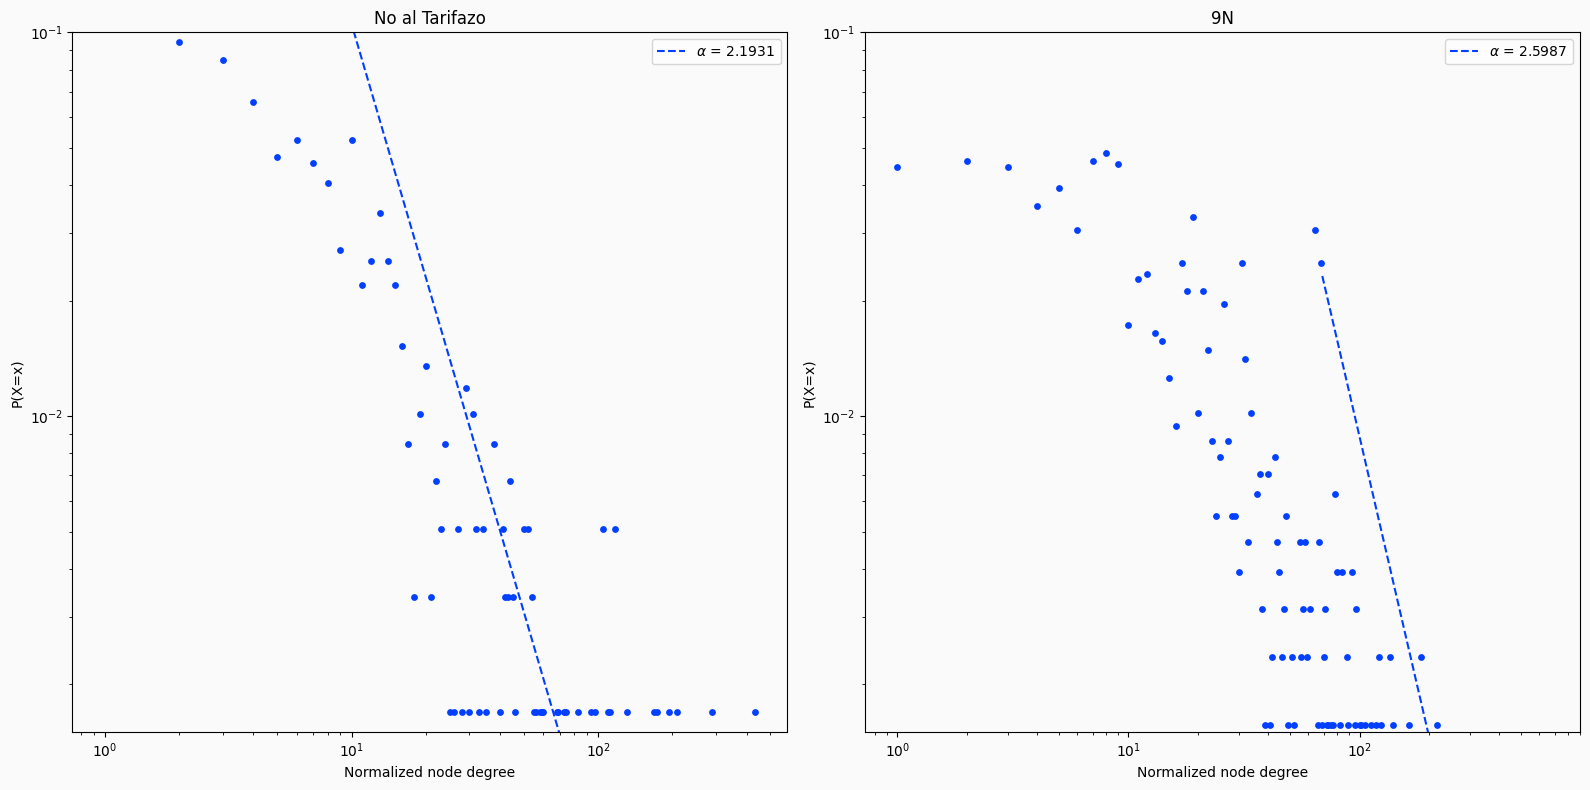

In [24]:
plt.style.use('seaborn-v0_8-bright')

fig, axs = plt.subplots(1, 2, facecolor="#fafafa")
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("#fafafa")

fig.set_size_inches(16,8)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].scatter(arr_pdf_points_nat[0][0], arr_pdf_points_nat[0][1], marker="o", s=15, alpha=1)
plfit_nat.power_law.plot_pdf(label="$\\alpha$ = " + str(round(plfit_nat.alpha, 4)), ax=axs[0], linestyle='--')
axs[0].set_ylim(0.0015, 0.1)

axs[0].set_xlabel("Normalized node degree")
axs[0].set_ylabel("P(X=x)")
axs[0].set_title("No al Tarifazo")
axs[0].legend()

"""with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_nat = axs[0].inset_axes([0.1, 0.1, 0.4, 0.4])

    ins_ax_nat.set_facecolor('xkcd:white')
    for spine in ins_ax_nat.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 

    ins_ax_nat.set_xscale('log')
    ins_ax_nat.set_yscale('log')

    ins_ax_nat.scatter(arr_ccdf_points_nat[0][0], arr_ccdf_points_nat[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_nat.set_title("CCDF")
    #ins_ax_nat.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_nat.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_nat.tick_params(labelsize=8)

    plfit_nat.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_nat.alpha, 5)), ax=ins_ax_nat, linestyle='--', c='#ff7f0e')"""
    

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].scatter(arr_pdf_points_9n[0][0], arr_pdf_points_9n[0][1], marker="o", s=15, alpha=1)
plfit_9n.power_law.plot_pdf(label="$\\alpha$ = " + str(round(plfit_9n.alpha, 4)), ax=axs[1], linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
axs[1].legend() #loc = "center right"
axs[1].set_ylim(0.0015, 0.1)

axs[1].set_xlabel("Normalized node degree")
axs[1].set_ylabel("P(X=x)")
axs[1].set_title("9N")
"""
with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_9n = axs[1].inset_axes([0.1, 0.1, 0.4, 0.4])

    ins_ax_9n.set_facecolor('xkcd:white')
    for spine in ins_ax_9n.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 

    ins_ax_9n.set_xscale('log')
    ins_ax_9n.set_yscale('log')

    ins_ax_9n.scatter(arr_ccdf_points_9n[0][0], arr_ccdf_points_9n[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_9n.set_title("CCDF")
    #ins_ax_9n.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_9n.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_9n.tick_params(labelsize=8)

    plfit_9n.power_law.plot_ccdf(label="powerlaw, $\\alpha$ = " + str(round(plfit_9n.alpha, 5)), ax=ins_ax_9n, linestyle='--', c='#ff7f0e')"""



    
plt.tight_layout()
plt.savefig("plots/PDF-CCDF_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + ".png")
plt.show()

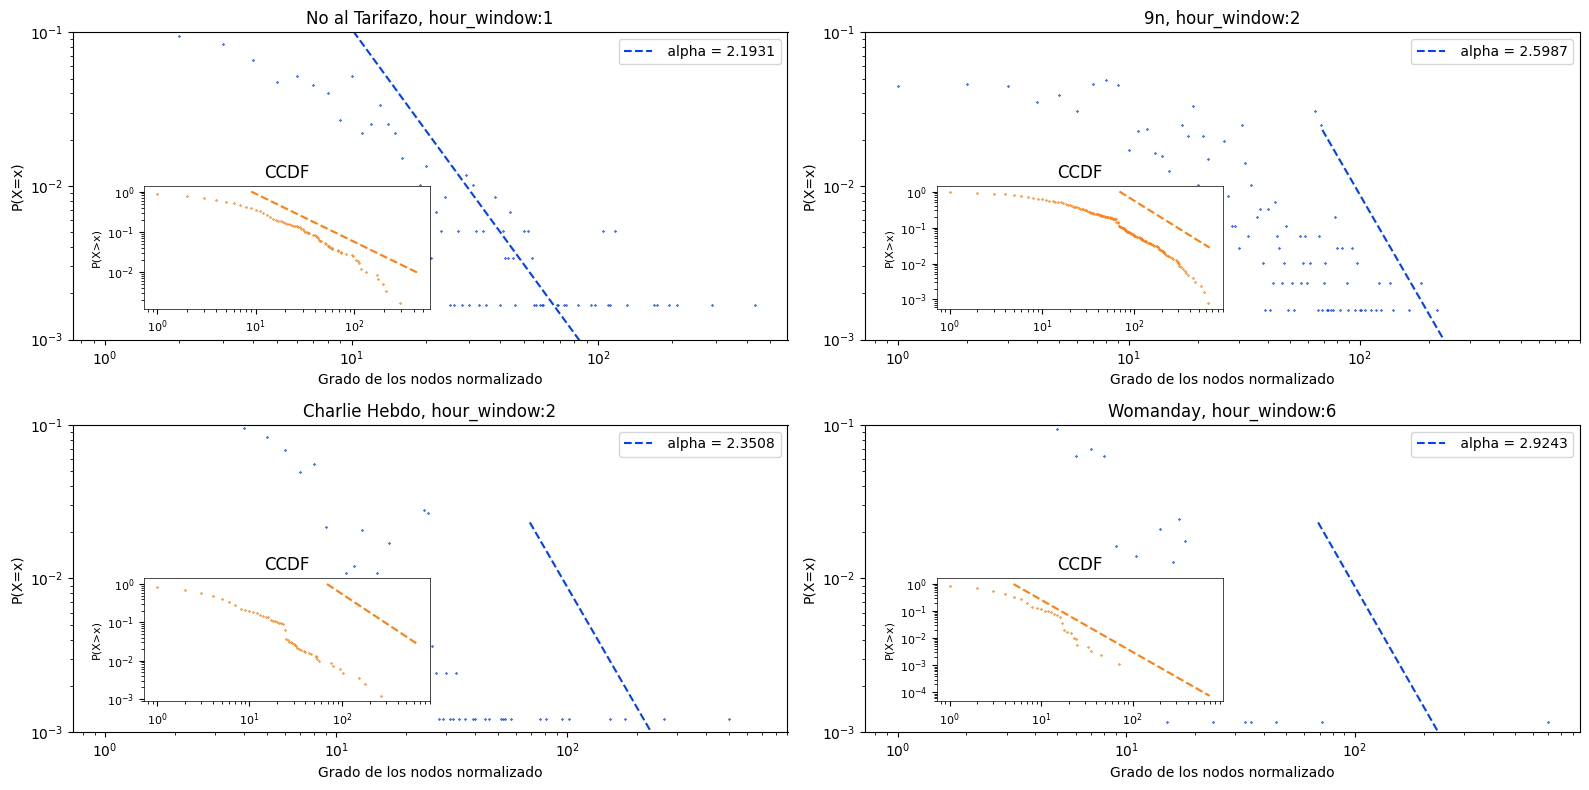

In [25]:
plt.style.use('seaborn-v0_8-bright')

fig, axs = plt.subplots(2, 2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")

fig.set_size_inches(16,8)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].scatter(arr_pdf_points_nat[0][0], arr_pdf_points_nat[0][1], marker="x", s=1, alpha=0.7)
plfit_nat.power_law.plot_pdf(label=" alpha = " + str(round(plfit_nat.alpha, 4)), ax=axs[0], linestyle='--')
axs[0].set_ylim(0.001, 0.1)

axs[0].set_xlabel("Grado de los nodos normalizado")
axs[0].set_ylabel("P(X=x)")
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))
axs[0].legend()

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_nat = axs[0].inset_axes([0.1, 0.1, 0.4, 0.4])

    ins_ax_nat.set_facecolor('xkcd:white')
    for spine in ins_ax_nat.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 

    ins_ax_nat.set_xscale('log')
    ins_ax_nat.set_yscale('log')

    ins_ax_nat.scatter(arr_ccdf_points_nat[0][0], arr_ccdf_points_nat[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_nat.set_title("CCDF")
    #ins_ax_nat.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_nat.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_nat.tick_params(labelsize=8)

    plfit_nat.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_nat.alpha, 5)), ax=ins_ax_nat, linestyle='--', c='#ff7f0e')
    

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].scatter(arr_pdf_points_9n[0][0], arr_pdf_points_9n[0][1], marker="x", s=1, alpha=0.7)
plfit_9n.power_law.plot_pdf(label=" alpha = " + str(round(plfit_9n.alpha, 4)), ax=axs[1], linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
axs[1].legend()
axs[1].set_ylim(0.001, 0.1)

axs[1].set_xlabel("Grado de los nodos normalizado")
axs[1].set_ylabel("P(X=x)")
axs[1].set_title("9n, hour_window:" + str(hour_window_9n))

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_9n = axs[1].inset_axes([0.1, 0.1, 0.4, 0.4])

    ins_ax_9n.set_facecolor('xkcd:white')
    for spine in ins_ax_9n.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 

    ins_ax_9n.set_xscale('log')
    ins_ax_9n.set_yscale('log')

    ins_ax_9n.scatter(arr_ccdf_points_9n[0][0], arr_ccdf_points_9n[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_9n.set_title("CCDF")
    #ins_ax_9n.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_9n.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_9n.tick_params(labelsize=8)

    plfit_9n.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_9n.alpha, 5)), ax=ins_ax_9n, linestyle='--', c='#ff7f0e')


axs[2].set_xscale('log')
axs[2].set_yscale('log')

axs[2].scatter(arr_pdf_points_ch[0][0], arr_pdf_points_ch[0][1], marker="x", s=1, alpha=0.7)
plfit_9n.power_law.plot_pdf(label=" alpha = " + str(round(plfit_ch.alpha, 4)), ax=axs[2], linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
axs[2].legend()
axs[2].set_ylim(0.001, 0.1)

axs[2].set_xlabel("Grado de los nodos normalizado")
axs[2].set_ylabel("P(X=x)")
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch))

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_ch = axs[2].inset_axes([0.1, 0.1, 0.4, 0.4])

    ins_ax_ch.set_facecolor('xkcd:white')
    for spine in ins_ax_ch.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 

    ins_ax_ch.set_xscale('log')
    ins_ax_ch.set_yscale('log')

    ins_ax_ch.scatter(arr_ccdf_points_ch[0][0], arr_ccdf_points_ch[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_ch.set_title("CCDF")
    #ins_ax_ch.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_ch.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_ch.tick_params(labelsize=8)

    plfit_9n.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_ch.alpha, 5)), ax=ins_ax_ch, linestyle='--', c='#ff7f0e')

axs[3].set_xscale('log')
axs[3].set_yscale('log')

axs[3].scatter(arr_pdf_points_wd[0][0], arr_pdf_points_wd[0][1], marker="x", s=1, alpha=0.7)
plfit_9n.power_law.plot_pdf(label=" alpha = " + str(round(plfit_wd.alpha, 4)), ax=axs[3], linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
axs[3].legend()
axs[3].set_ylim(0.001, 0.1)

axs[3].set_xlabel("Grado de los nodos normalizado")
axs[3].set_ylabel("P(X=x)")
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd))

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_wd = axs[3].inset_axes([0.1, 0.1, 0.4, 0.4])
    ins_ax_wd.set_facecolor('xkcd:white')
    for spine in ins_ax_wd.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ins_ax_wd.set_xscale('log')
    ins_ax_wd.set_yscale('log')

    ins_ax_wd.scatter(arr_ccdf_points_wd[0][0], arr_ccdf_points_wd[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_wd.set_title("CCDF")
    #ins_ax_wd.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_wd.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_wd.tick_params(labelsize=8)

    plfit_wd.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_wd.alpha, 5)), ax=ins_ax_wd, linestyle='--', c='#ff7f0e')
    
plt.tight_layout()
plt.savefig("plots/PDF-CCDF_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

# AUTOSIMILITUD EN LAS REDES

## Grado medio por Kt

In [26]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200

dict_hora_nat = {}
G_nat = nx.read_gexf(graphs_folder + "nodes_hashtag/nat/" + str(hour_window_nat) + '/' + HORA_CRITICA_NAT + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_nat.keys():
        # Se crea el subgrafo basandose en el threshold seleccionado
        F = thresh_normalization(G_nat,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_nat[threshold] = calc_avg_degree(F)


dict_hora_9n = {}
G_9n = nx.read_gexf(graphs_folder + "nodes_hashtag/9n/" + str(hour_window_9n) + '/' + HORA_CRITICA_9N + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_9n.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_9n,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_9n[threshold] = calc_avg_degree(F)


dict_hora_ch = {}
G_ch = nx.read_gexf(graphs_folder + "nodes_hashtag/ch/" + str(hour_window_ch) + '/' + HORA_CRITICA_CH + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_ch.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_ch,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_ch[threshold] = calc_avg_degree(F)

dict_hora_wd = {}
G_wd = nx.read_gexf(graphs_folder + "nodes_hashtag/wd/" + str(hour_window_wd) + '/' + HORA_CRITICA_WD + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_wd.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_wd,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_wd[threshold] = calc_avg_degree(F)

 36%|███▌      | 72/200 [00:00<00:00, 732.63it/s]


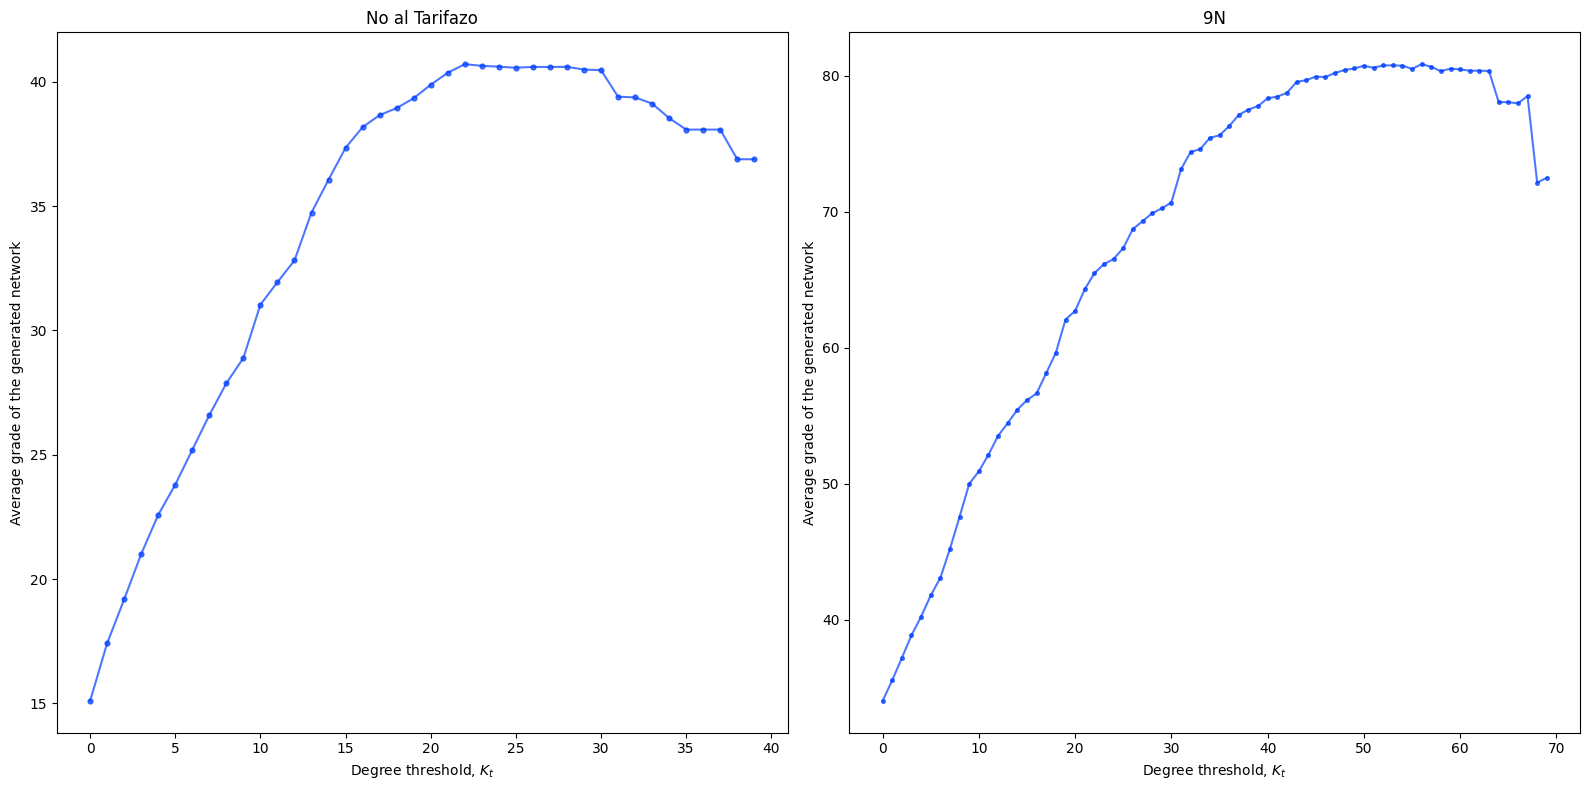

In [27]:
plt.style.use('seaborn-v0_8-bright')

alpha=0.7

fig, axs = plt.subplots(1,2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8) 

axs[0].plot(list(dict_hora_nat.keys())[0:40], list(dict_hora_nat.values())[0:40], alpha=0.7)
axs[0].scatter(list(dict_hora_nat.keys())[0:40], list(dict_hora_nat.values())[0:40], s=12, alpha=alpha)
axs[0].set_title("No al Tarifazo")

"""with plt.style.context('seaborn-v0_8-bright'):
    ax1_inset = axs[0].inset_axes([0.5, 0.25, 0.4, 0.4])
    ax1_inset.set_facecolor('xkcd:white')
    for spine in ax1_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    #ax1_inset = inset_axes(ax1, width="40%", height="40%", loc="center right")  # Dimensiones y ubicación del inset
    ax1_inset.plot(list(dict_hora_nat.keys()), list(dict_hora_nat.values()), alpha=0.7, c='#ff7f0e')
    ax1_inset.scatter(list(dict_hora_nat.keys()), list(dict_hora_nat.values()), s=4, alpha=alpha, c='#ff7f0e')"""

axs[0].set_ylabel("Average grade of the generated network")
axs[0].set_xlabel("Degree threshold, $K_t$")


axs[1].plot(list(dict_hora_9n.keys())[0:70], list(dict_hora_9n.values())[0:70], alpha=alpha)
axs[1].scatter(list(dict_hora_9n.keys())[0:70], list(dict_hora_9n.values())[0:70], s=7, alpha=alpha)
axs[1].set_title("9N")

"""with plt.style.context('seaborn-v0_8-bright'):
    ax2_inset = axs[1].inset_axes([0.5, 0.25, 0.4, 0.4])
    ax2_inset.set_facecolor('xkcd:white')
    for spine in ax2_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    #ax2_inset = inset_axes(ax2, width="40%", height="40%", loc="center right")  # Dimensiones y ubicación del inset
    ax2_inset.plot(list(dict_hora_9n.keys()), list(dict_hora_9n.values()), alpha=alpha, c='#ff7f0e')
    ax2_inset.scatter(list(dict_hora_9n.keys()), list(dict_hora_9n.values()), s=4, alpha=alpha, c='#ff7f0e')
    ax2_inset.get_xaxis().set_visible(True)"""

axs[1].set_ylabel("Average grade of the generated network")
axs[1].set_xlabel("Degree threshold, $K_t$")


plt.tight_layout()
plt.savefig(plots_folder + "avg_deg_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + ".png")
plt.show()

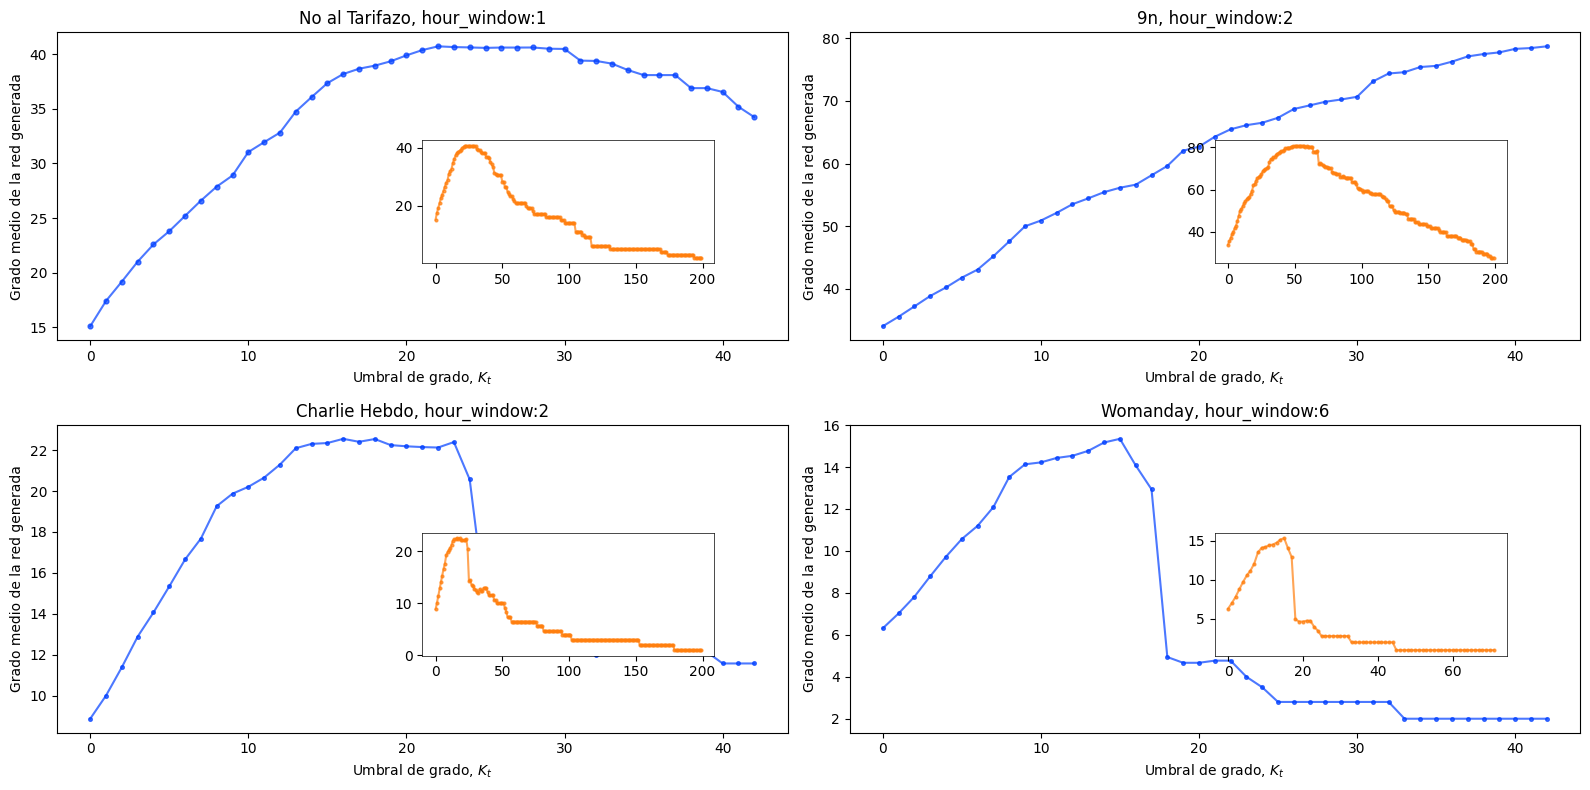

In [28]:
plt.style.use('seaborn-v0_8-bright')

alpha=0.7

fig, axs = plt.subplots(2,2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8) 

axs[0].plot(list(dict_hora_nat.keys())[0:43], list(dict_hora_nat.values())[0:43], alpha=0.7)
axs[0].scatter(list(dict_hora_nat.keys())[0:43], list(dict_hora_nat.values())[0:43], s=12, alpha=alpha)
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))

with plt.style.context('seaborn-v0_8-bright'):
    ax1_inset = axs[0].inset_axes([0.5, 0.25, 0.4, 0.4])
    ax1_inset.set_facecolor('xkcd:white')
    for spine in ax1_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    #ax1_inset = inset_axes(ax1, width="40%", height="40%", loc="center right")  # Dimensiones y ubicación del inset
    ax1_inset.plot(list(dict_hora_nat.keys()), list(dict_hora_nat.values()), alpha=0.7, c='#ff7f0e')
    ax1_inset.scatter(list(dict_hora_nat.keys()), list(dict_hora_nat.values()), s=4, alpha=alpha, c='#ff7f0e')

axs[0].set_ylabel("Grado medio de la red generada")
axs[0].set_xlabel("Umbral de grado, $K_t$")


axs[1].plot(list(dict_hora_9n.keys())[0:43], list(dict_hora_9n.values())[0:43], alpha=alpha)
axs[1].scatter(list(dict_hora_9n.keys())[0:43], list(dict_hora_9n.values())[0:43], s=7, alpha=alpha)
axs[1].set_title("9n, hour_window:" + str(hour_window_9n))

with plt.style.context('seaborn-v0_8-bright'):
    ax2_inset = axs[1].inset_axes([0.5, 0.25, 0.4, 0.4])
    ax2_inset.set_facecolor('xkcd:white')
    for spine in ax2_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    #ax2_inset = inset_axes(ax2, width="40%", height="40%", loc="center right")  # Dimensiones y ubicación del inset
    ax2_inset.plot(list(dict_hora_9n.keys()), list(dict_hora_9n.values()), alpha=alpha, c='#ff7f0e')
    ax2_inset.scatter(list(dict_hora_9n.keys()), list(dict_hora_9n.values()), s=4, alpha=alpha, c='#ff7f0e')
    ax2_inset.get_xaxis().set_visible(True)

axs[1].set_ylabel("Grado medio de la red generada")
axs[1].set_xlabel("Umbral de grado, $K_t$")


axs[2].plot(list(dict_hora_ch.keys())[0:43], list(dict_hora_ch.values())[0:43], alpha=alpha)
axs[2].scatter(list(dict_hora_ch.keys())[0:43], list(dict_hora_ch.values())[0:43], s=7, alpha=alpha)
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch))

with plt.style.context('seaborn-v0_8-bright'):
    ax3_inset = axs[2].inset_axes([0.5, 0.25, 0.4, 0.4])
    ax3_inset.set_facecolor('xkcd:white')
    for spine in ax3_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    #ax2_inset = inset_axes(ax2, width="40%", height="40%", loc="center right")  # Dimensiones y ubicación del inset
    ax3_inset.plot(list(dict_hora_ch.keys()), list(dict_hora_ch.values()), alpha=alpha, c='#ff7f0e')
    ax3_inset.scatter(list(dict_hora_ch.keys()), list(dict_hora_ch.values()), s=4, alpha=alpha, c='#ff7f0e')
    ax3_inset.get_xaxis().set_visible(True)

axs[2].set_ylabel("Grado medio de la red generada")
axs[2].set_xlabel("Umbral de grado, $K_t$")


axs[3].plot(list(dict_hora_wd.keys())[0:43], list(dict_hora_wd.values())[0:43], alpha=alpha)
axs[3].scatter(list(dict_hora_wd.keys())[0:43], list(dict_hora_wd.values())[0:43], s=7, alpha=alpha)
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd))

"""for index, spine in enumerate(axs[3].spines.values()):
        spine.set_visible(True)
        spine.set_linewidth(0.5)  
        spine.set_color("black") """

with plt.style.context('seaborn-v0_8-bright'):
    ax4_inset = axs[3].inset_axes([0.5, 0.25, 0.4, 0.4])
    ax4_inset.set_facecolor('xkcd:white')
    for spine in ax4_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    #ax2_inset = inset_axes(ax2, width="40%", height="40%", loc="center right")  # Dimensiones y ubicación del inset
    ax4_inset.plot(list(dict_hora_wd.keys()), list(dict_hora_wd.values()), alpha=alpha, c='#ff7f0e')
    ax4_inset.scatter(list(dict_hora_wd.keys()), list(dict_hora_wd.values()), s=4, alpha=alpha, c='#ff7f0e')
    ax4_inset.get_xaxis().set_visible(True)

axs[3].set_ylabel("Grado medio de la red generada")
axs[3].set_xlabel("Umbral de grado, $K_t$")

plt.tight_layout()
plt.savefig(plots_folder + "avg_deg_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

## Autosimilitud

In [29]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500

# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/')
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/')
dict_thres_avg_clust_wd_h, dict_norm_int_deg_wd_h = calc_self_sim(HORA_CRITICA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/')

 14%|█▍        | 72/500 [00:00<00:00, 767.37it/s]


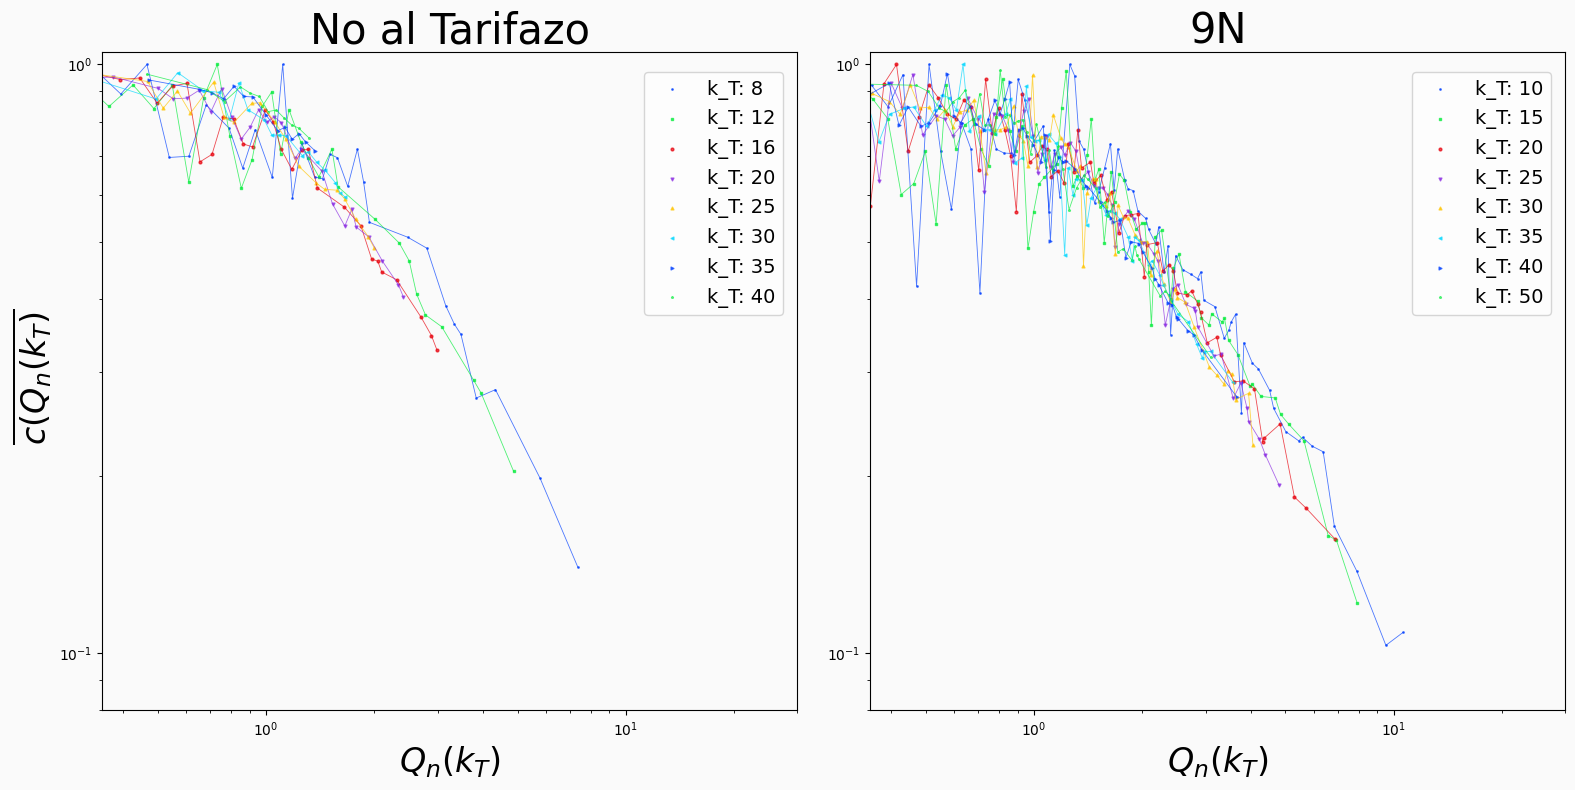

In [30]:
plt.style.use('seaborn-v0_8-bright')

# Dado un diccionario con K_t como claves y como valores diccionarios con internal degrees como clave y la media de coeficiente de clusterización
# de los nodos que tienen dicho internal degree como valor, plotea el scatter con la clave en eje X y los valores en eje Y
# Plotea tantos tipos como elementos haya en arr_index(esos indices en concreto)

# Los valores de Kt que se van a representar
arr_kt_plot_nat = [8,12,16,20,25,30,35,40]
arr_kt_plot_9n = [10,15,20,25,30,35,40,50]
arr_kt_plot_ch = [9,13,15,18,20]
# arr_kt_plot_ch = [5,7,9,12,15,17]
arr_kt_plot_wd = [2,3,5,7,9,11]



markers = get_all_markers()
alpha = 0.7

fig, axs = plt.subplots(1, 2, facecolor="#fafafa")
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("#fafafa")
fig.set_size_inches(16,8) 


for index, kt in enumerate(arr_kt_plot_nat):
    if kt in dict_norm_int_deg_nat_h.keys():
        points_x = list(dict_norm_int_deg_nat_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_nat_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[0].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[0].scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'k_T: {kt}')        

axs[0].set_xlabel("$Q_i(\\theta_t)$", fontsize=24)

axs[0].set_xlabel("$Q_n(k_T)$", fontsize=24)
axs[0].set_ylabel(" $\\overline{c(Q_n(k_T)}$", fontsize=24)
axs[0].set_xscale('log')  
axs[0].set_yscale('log')      
axs[0].set_ylim(0.08, 1.05)
axs[0].set_xlim(0.35, 30)
axs[0].legend(loc=(0.78, 0.6), prop={'size': 14})
axs[0].set_title("No al Tarifazo", fontsize=30)


for index, kt in enumerate(arr_kt_plot_9n):
    if kt in dict_norm_int_deg_9n_h.keys():
        points_x = list(dict_norm_int_deg_9n_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_9n_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[1].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[1].scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'k_T: {kt}')        

axs[1].set_xlabel("$Q_n(k_T)$", fontsize=24)
#axs[1].set_ylabel(" $\\overline{c(k_i(\\theta_t))}$", fontsize=12)
axs[1].set_xscale('log')  
axs[1].set_yscale('log')      
axs[1].set_ylim(0.08, 1.05)
axs[1].set_xlim(0.35, 30)
axs[1].legend(loc=(0.78, 0.6), prop={'size': 14})
axs[1].set_title("9N", fontsize=30)


plt.tight_layout()
plt.savefig(plots_folder + "self_similarity_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + ".png")
plt.show()

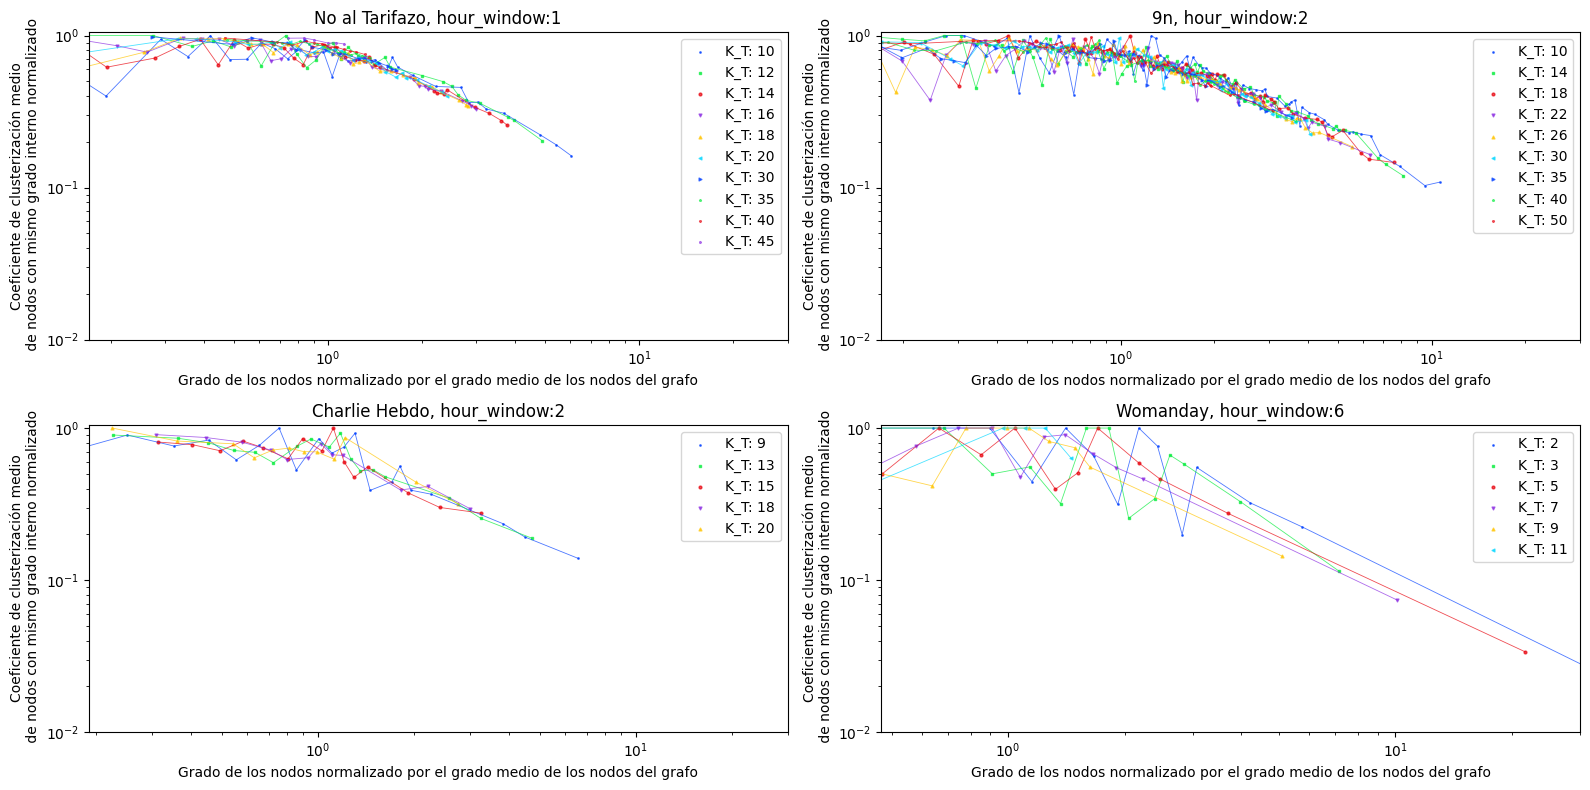

In [31]:
plt.style.use('seaborn-v0_8-bright')

# Dado un diccionario con K_t como claves y como valores diccionarios con internal degrees como clave y la media de coeficiente de clusterización
# de los nodos que tienen dicho internal degree como valor, plotea el scatter con la clave en eje X y los valores en eje Y
# Plotea tantos tipos como elementos haya en arr_index(esos indices en concreto)

# Los valores de Kt que se van a representar
arr_kt_plot_nat = [10,12,14,16,18,20,30,35,40,45]
arr_kt_plot_9n = [10,14,18,22,26,30, 35, 40, 50]
arr_kt_plot_ch = [9,13,15,18,20]
# arr_kt_plot_ch = [5,7,9,12,15,17]
arr_kt_plot_wd = [2,3,5,7,9,11]



markers = get_all_markers()
alpha = 0.7

fig, axs = plt.subplots(2, 2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8) 


for index, kt in enumerate(arr_kt_plot_nat):
    if kt in dict_norm_int_deg_nat_h.keys():
        points_x = list(dict_norm_int_deg_nat_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_nat_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[0].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[0].scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

axs[0].set_xlabel("Grado de los nodos normalizado por el grado medio de los nodos del grafo")
axs[0].set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
axs[0].set_xscale('log')  
axs[0].set_yscale('log')      
axs[0].set_ylim(0.01, 1.05)
axs[0].set_xlim(0.17, 30)
axs[0].legend()
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))


for index, kt in enumerate(arr_kt_plot_9n):
    if kt in dict_norm_int_deg_9n_h.keys():
        points_x = list(dict_norm_int_deg_9n_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_9n_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[1].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[1].scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

axs[1].set_xlabel("Grado de los nodos normalizado por el grado medio de los nodos del grafo")
axs[1].set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
axs[1].set_xscale('log')  
axs[1].set_yscale('log')      
axs[1].set_ylim(0.01, 1.05)
axs[1].set_xlim(0.17, 30)
axs[1].legend()
axs[1].set_title("9n, hour_window:" + str(hour_window_9n))


for index, kt in enumerate(arr_kt_plot_ch):
    if kt in dict_norm_int_deg_ch_h.keys():
        points_x = list(dict_norm_int_deg_ch_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_ch_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_ch_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[2].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[2].scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

axs[2].set_xlabel("Grado de los nodos normalizado por el grado medio de los nodos del grafo")
axs[2].set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
axs[2].set_xscale('log')  
axs[2].set_yscale('log')      
axs[2].set_ylim(0.01, 1.05)
axs[2].set_xlim(0.19, 30)
axs[2].legend()
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch))


for index, kt in enumerate(arr_kt_plot_wd):
    if kt in dict_norm_int_deg_wd_h.keys():
        points_x = list(dict_norm_int_deg_wd_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_wd_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_wd_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[3].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[3].scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

axs[3].set_xlabel("Grado de los nodos normalizado por el grado medio de los nodos del grafo")
axs[3].set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
axs[3].set_xscale('log')  
axs[3].set_yscale('log')      
axs[3].set_ylim(0.01, 1.05)
axs[3].set_xlim(0.47, 30)
axs[3].legend()
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd))

plt.tight_layout()
plt.savefig(plots_folder + "self_similarity_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

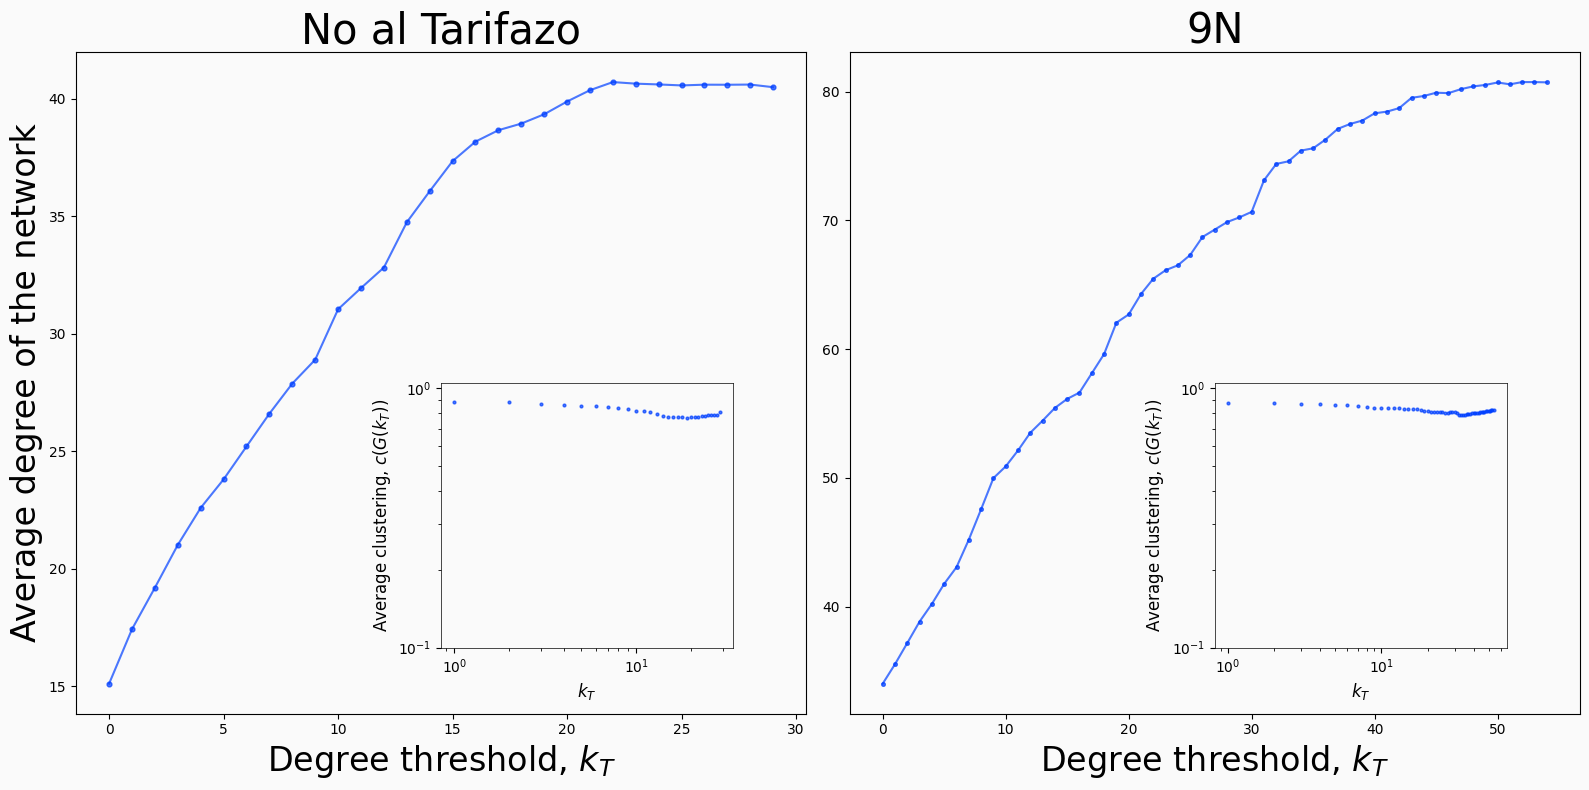

In [32]:
plt.style.use('seaborn-v0_8-bright')

alpha=0.7
# Máximos valores de Kt identificados para que no se observen errores de tamaño finito
supreme_nat = 30
supreme_9n = 55

fig, axs = plt.subplots(1,2, facecolor="#fafafa")
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("#fafafa")
fig.set_size_inches(16,8) 

axs[0].plot(list(dict_hora_nat.keys())[0:supreme_nat], list(dict_hora_nat.values())[0:supreme_nat], alpha=0.7)
axs[0].scatter(list(dict_hora_nat.keys())[0:supreme_nat], list(dict_hora_nat.values())[0:supreme_nat], s=12, alpha=alpha)
axs[0].set_title("No al Tarifazo", fontsize=30)

with plt.style.context('seaborn-v0_8-bright'):
    ax1_inset = axs[0].inset_axes([0.5, 0.1, 0.4, 0.4])
    ax1_inset.set_facecolor('#fafafa')
    for spine in ax1_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 

    
    ax1_inset.set_xscale('log')  
    ax1_inset.set_yscale('log')      
    ax1_inset.set_ylim(0.1, 1.05)     

    # Obtener las claves y los valores del diccionario
    kt_nat = list(dict_thres_avg_clust_nat_h.keys())[:supreme_nat]
    clust_nat = list(dict_thres_avg_clust_nat_h.values())[:supreme_nat]
    ax1_inset.scatter(kt_nat, clust_nat, s=4, alpha=alpha)
    ax1_inset.set_xlabel("$k_T$", fontsize=12)
    ax1_inset.set_ylabel("Average clustering, $c(G(k_T))$", fontsize=12)
    #ax1.legend(["max K_t posible: " + str(int(max(kt_nat)))])
    
axs[0].set_ylabel("Average degree of the network", fontsize=24)
axs[0].set_xlabel("Degree threshold, $k_T$", fontsize=24)


axs[1].plot(list(dict_hora_9n.keys())[0:supreme_9n], list(dict_hora_9n.values())[0:supreme_9n], alpha=alpha)
axs[1].scatter(list(dict_hora_9n.keys())[0:supreme_9n], list(dict_hora_9n.values())[0:supreme_9n], s=7, alpha=alpha)
axs[1].set_title("9N", fontsize=30)

with plt.style.context('seaborn-v0_8-bright'):
    ax2_inset = axs[1].inset_axes([0.5, 0.1, 0.4, 0.4])
    ax2_inset.set_facecolor('#fafafa')
    for spine in ax2_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    #ax2_inset = inset_axes(ax2, width="40%", height="40%", loc="center right")  # Dimensiones y ubicación del inset
    
    ax2_inset.set_xscale('log')  
    ax2_inset.set_yscale('log')      
    ax2_inset.set_ylim(0.1, 1.05)  
    # Obtener las claves y los valores del diccionario
    kt_9n = list(dict_thres_avg_clust_9n_h.keys())[:supreme_9n]
    clust_9n = list(dict_thres_avg_clust_9n_h.values())[:supreme_9n]
    ax2_inset.scatter(kt_9n, clust_9n, s=4, alpha=alpha)
    ax2_inset.set_xlabel("$k_T$", fontsize=12)
    ax2_inset.set_ylabel("Average clustering, $c(G(k_T))$", fontsize=12)
    ax2_inset.get_xaxis().set_visible(True)

#axs[1].set_ylabel("Average degree of the network", fontsize=24)
axs[1].set_xlabel("Degree threshold, $k_T$", fontsize=24)

plt.tight_layout()
plt.savefig(plots_folder + "avg_deg_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + ".png")
plt.show()

## Clustering promedio

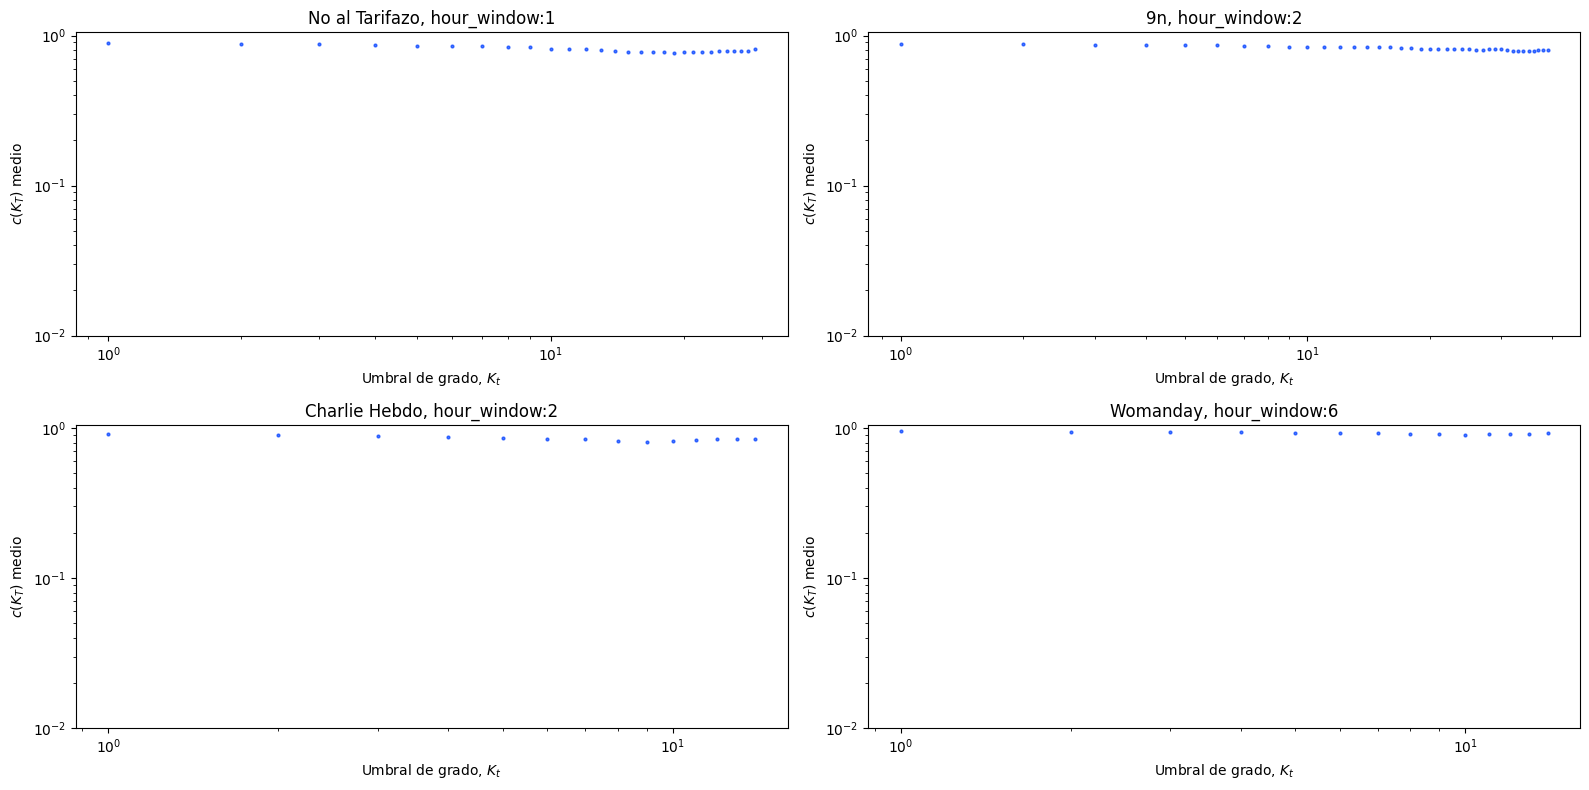

In [33]:
plt.style.use('seaborn-v0_8-bright')

# Máximos valores de Kt identificados para que no se observen errores de tamaño finito
supreme_nat = 30
supreme_9n = 40
supreme_ch = 15
supreme_wd = 15

markers = get_all_markers()
alpha = 0.7

fig, axs= plt.subplots(2, 2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")

fig.set_size_inches(16,8) 

axs[0].set_xscale('log')  
axs[0].set_yscale('log')      
axs[0].set_ylim(0.01, 1.05)     

# Obtener las claves y los valores del diccionario
kt_nat = list(dict_thres_avg_clust_nat_h.keys())[:supreme_nat]
clust_nat = list(dict_thres_avg_clust_nat_h.values())[:supreme_nat]

axs[0].scatter(kt_nat, clust_nat, s=4, alpha=alpha)

axs[0].set_xlabel("Umbral de grado, $K_t$")
axs[0].set_ylabel("$c(K_T)$ medio")
#ax1.legend(["max K_t posible: " + str(int(max(kt_nat)))])
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))


axs[1].set_xscale('log')  
axs[1].set_yscale('log')      
axs[1].set_ylim(0.01, 1.05)  

# Obtener las claves y los valores del diccionario
kt_9n = list(dict_thres_avg_clust_9n_h.keys())[:supreme_9n]
clust_9n = list(dict_thres_avg_clust_9n_h.values())[:supreme_9n]

axs[1].scatter(kt_9n, clust_9n, s=4, alpha=alpha)

axs[1].set_xlabel("Umbral de grado, $K_t$")
axs[1].set_ylabel("$c(K_T)$ medio")
#ax2.legend(["max K_t posible: " + str(int(max(kt_9n)))])
axs[1].set_title("9n, hour_window:" + str(hour_window_9n))


axs[2].set_xscale('log')  
axs[2].set_yscale('log')      
axs[2].set_ylim(0.01, 1.05)     

# Obtener las claves y los valores del diccionario
kt_ch = list(dict_thres_avg_clust_ch_h.keys())[:supreme_ch]
clust_ch = list(dict_thres_avg_clust_ch_h.values())[:supreme_ch]

axs[2].scatter(kt_ch, clust_ch, s=4, alpha=alpha)

axs[2].set_xlabel("Umbral de grado, $K_t$")
axs[2].set_ylabel("$c(K_T)$ medio")
#ax2.legend(["max K_t posible: " + str(int(max(kt_9n)))])
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch))


axs[3].set_xscale('log')  
axs[3].set_yscale('log')      
axs[3].set_ylim(0.01, 1.05)     

# Obtener las claves y los valores del diccionario
kt_wd = list(dict_thres_avg_clust_wd_h.keys())[:supreme_wd]
clust_wd = list(dict_thres_avg_clust_wd_h.values())[:supreme_wd]

axs[3].scatter(kt_wd, clust_wd, s=4, alpha=alpha)

axs[3].set_xlabel("Umbral de grado, $K_t$")
axs[3].set_ylabel("$c(K_T)$ medio")
#ax2.legend(["max K_t posible: " + str(int(max(kt_9n)))])
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd))


plt.tight_layout()
plt.savefig(plots_folder + "avg_clust_kt_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

In [34]:
arr_kt_plot_nat = [10,12,14,15,16,18,20]
_, arr_deg_prob_nat, arr_deg_comp_cum_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_nat, exp=False, norm=True)
#calc_yerali(hora, graphs_folder, plots_folder, plfit=True, normalize=False, show_comparative=False, only_ntamas=False)


arr_kt_plot_9n = [10,14,18,22,26,30]
_, arr_deg_prob_9n, arr_deg_comp_cum_9n = calc_degree_distribution(HORA_CRITICA_9N,  "9n/" + str(hour_window_9n) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_9n, exp=False, norm=True)
#calc_yerali(hora, graphs_folder, plots_folder, plfit=True, normalize=False, show_comparative=False, only_ntamas=False)

arr_kt_plot_ch = [5,7,9,11,13,15]
_, arr_deg_prob_ch, arr_deg_comp_cum_ch = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch, exp=False, norm=True)
#calc_yerali(hora, graphs_folder, plots_folder, plfit=True, normalize=False, show_comparative=False, only_ntamas=False)

arr_kt_plot_wd = [2,3,4,5,6]
_, arr_deg_prob_wd, arr_deg_comp_cum_wd = calc_degree_distribution(HORA_CRITICA_WD,  "wd/" + str(hour_window_wd) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_wd, exp=False, norm=True)
#calc_yerali(hora, graphs_folder, plots_folder, plfit=True, normalize=False, show_comparative=False, only_ntamas=False)

100%|██████████| 7/7 [00:00<00:00, 124.53it/s]


0.9999999999999999
[0.09666667 0.16111111 0.19333333 0.19333333 0.19333333 0.25777778
 0.29       0.29       0.32222222 0.32222222 0.35444444 0.35444444
 0.35444444 0.35444444 0.35444444 0.35444444 0.35444444 0.35444444
 0.35444444 0.38666667 0.38666667 0.38666667 0.38666667 0.38666667
 0.38666667 0.38666667 0.38666667 0.38666667 0.38666667 0.38666667
 0.38666667 0.38666667 0.38666667 0.38666667 0.38666667 0.38666667
 0.41888889 0.41888889 0.41888889 0.41888889 0.41888889 0.41888889
 0.41888889 0.41888889 0.41888889 0.41888889 0.41888889 0.41888889
 0.41888889 0.41888889 0.41888889 0.41888889 0.41888889 0.45111111
 0.45111111 0.45111111 0.45111111 0.45111111 0.45111111 0.45111111
 0.45111111 0.45111111 0.45111111 0.45111111 0.45111111 0.45111111
 0.45111111 0.45111111 0.45111111 0.48333333 0.48333333 0.48333333
 0.48333333 0.48333333 0.48333333 0.48333333 0.48333333 0.48333333
 0.48333333 0.48333333 0.48333333 0.48333333 0.48333333 0.51555556
 0.51555556 0.51555556 0.51555556 0.5155555

100%|██████████| 6/6 [00:00<00:00, 519.05it/s]


1.0
[ 0.03929595  0.09823987  0.11788784  0.11788784  0.11788784  0.13753582
  0.15718379  0.17683176  0.17683176  0.17683176  0.17683176  0.19647974
  0.19647974  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771
  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771
  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771
  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771
  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771  0.21612771
  0.21612771  0.21612771  0.21612771  0.21612771  0.23577569  0.23577569
  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569
  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569
  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569
  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569  0.23577569
  0.23577569  0.25542366  0.25542366  0.25542366  0.25542366  0.25542366
  0.25542366  0.25542366  0.25542366  0.2554236

100%|██████████| 6/6 [00:00<00:00, 1389.07it/s]


1.0
[ 0.06518345  0.06518345  0.1303669   0.1303669   0.19555035  0.2607338
  0.2607338   0.2607338   0.2607338   0.2607338   0.32591725  0.32591725
  0.32591725  0.32591725  0.32591725  0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.3911007   0.3911007   0.3911007   0.3911007   0.3911007   0.3911007
  0.45628415  0.45628415  0.45628415  0.45628415  0.45628415  0.45628415
  0.45628415  0.45628415  0.45628415  0.45628415  0.456284

100%|██████████| 5/5 [00:00<00:00, 638.31it/s]

1.0
[ 0.12797992  0.12797992  0.12797992  0.12797992  0.25595985  0.25595985
  0.25595985  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977  0.38393977
  0.38393977  0.38393977  0.38393977  0.3839397

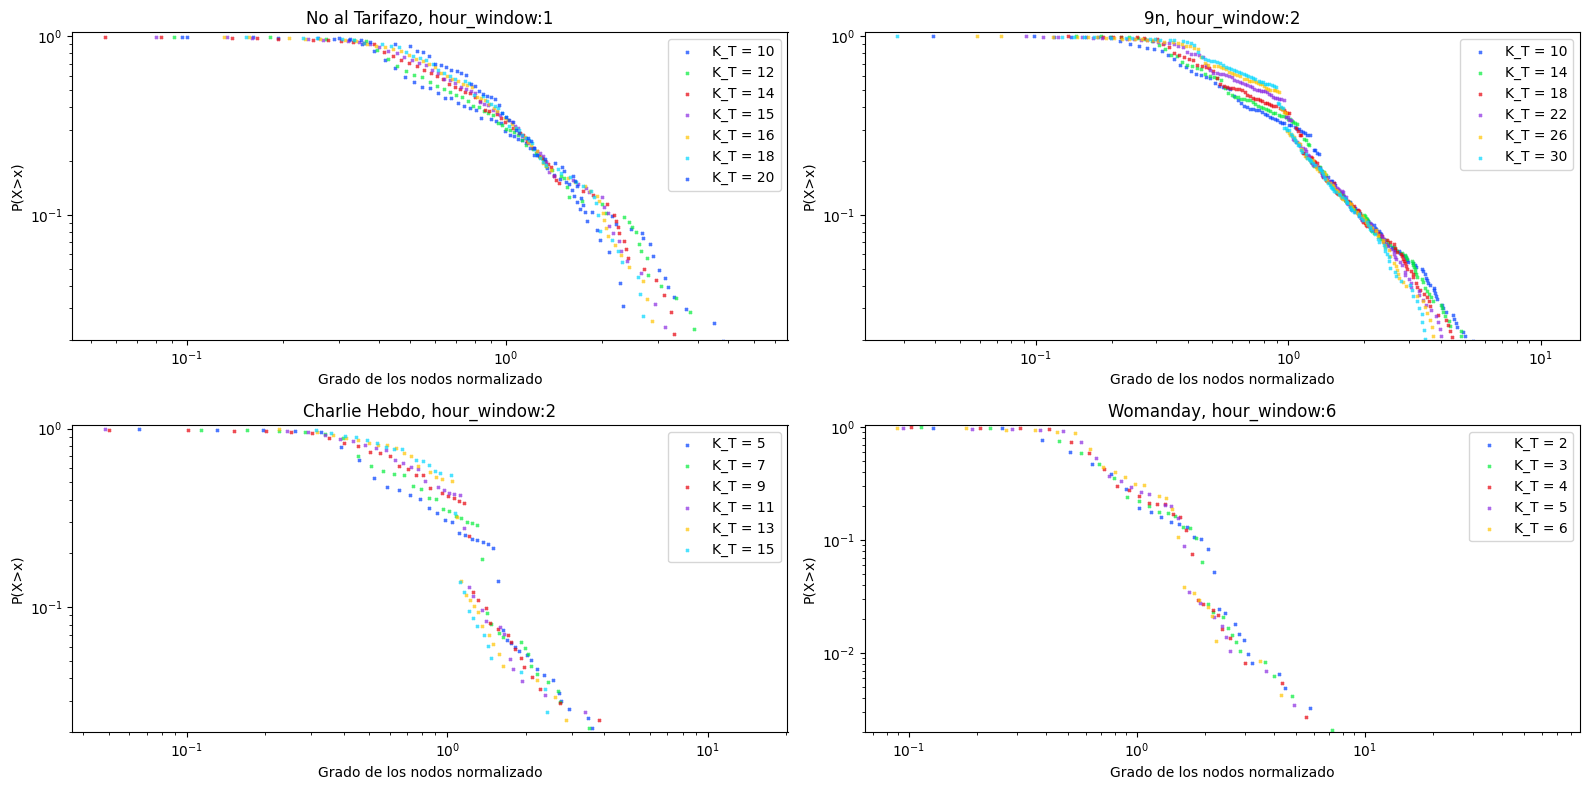

In [35]:
plt.style.use('seaborn-v0_8-bright')    

fig, axs = plt.subplots(2, 2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8)

dot_size=4
marker = "x"
alpha=0.7

for index, points in enumerate(arr_deg_comp_cum_nat):
    axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_nat[index]))
axs[0].legend()
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(0.02, 1.05)
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))
axs[0].set_xlabel("Grado de los nodos normalizado")
axs[0].set_ylabel("P(X>x)")

for index, points in enumerate(arr_deg_comp_cum_9n):
    axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_9n[index]))
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(0.02, 1.05)
axs[1].set_title("9n, hour_window:" + str(hour_window_9n))
axs[1].set_xlabel("Grado de los nodos normalizado")
axs[1].set_ylabel("P(X>x)")

for index, points in enumerate(arr_deg_comp_cum_ch):
    axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_ch[index]))
axs[2].legend()
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_ylim(0.02, 1.05)
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch))
axs[2].set_xlabel("Grado de los nodos normalizado")
axs[2].set_ylabel("P(X>x)")

for index, points in enumerate(arr_deg_comp_cum_wd):
    axs[3].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_wd[index]))
    # axs[3].plot(points[0], points[1])
axs[3].legend()
axs[3].set_xscale('log')
axs[3].set_yscale('log')
axs[3].set_ylim(0.002, 1.05)
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd))
axs[3].set_xlabel("Grado de los nodos normalizado")
axs[3].set_ylabel("P(X>x)")

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_Kts_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

## Uso de d-mercator

Los archivos de código relativos al uso de d-mercator se encuentran en la carpeta ```d-mercator/``` del presente repositorio.

## Grafos Filtrados

### Ajuste a ley de potencia de los grafos filtrados

In [14]:
def write_filtered_graph(MANIFESTACION, HORA_CRITICA, umbral, hour_window=1):

    # 9n
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/" + MANIFESTACION + '/' + str(hour_window) + '/' + HORA_CRITICA + ".gexf")
    nodos_original = G.number_of_nodes()
    aristas_original = G.number_of_edges()
    # Se queda con las aristas con peso mayor o igual a umbral
    G = create_filtered_graph(G, umbral)

    # Componente gigante del grafo
    Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
    G = G.subgraph(Gcc[0])

    nx.write_gexf(G, graphs_folder + "filtered/" + str(umbral) + '/'  + MANIFESTACION + '/' + str(hour_window) + '/' + HORA_CRITICA + ".gexf")

    # Escribimos el .edge (listo para usar dmercator)
    with open(graphs_folder + "filtered/" + str(umbral) + '/'  + MANIFESTACION + '/' + str(hour_window) + '/' + HORA_CRITICA + ".edge", "w") as f:
        for edge in G.edges():
            f.write(edge[0] + ' ' + edge[1] + '\n')
    print("Grafo", MANIFESTACION + ":" + HORA_CRITICA," (umbral", str(umbral) + ')', "reducido a", round(G.number_of_nodes()/nodos_original*100,2), "% en nodos y ", round(G.number_of_edges()/aristas_original*100, 2), "% en aristas.")

In [10]:
# Threshold empleado para cada manifestacion
umbral_nat = 5
umbral_9n = 5
umbral_ch = 5
umbral_wd = 2

In [19]:
HORA_CRITICA_WD = "422369"

In [20]:
# CREACIÓN DE LOS GRAFOS FILTRADOS

write_filtered_graph("nat", HORA_CRITICA_NAT, umbral_nat, hour_window_nat)
write_filtered_graph("9n", HORA_CRITICA_9N, umbral_9n, hour_window_9n)
write_filtered_graph("ch", HORA_CRITICA_CH, umbral_ch, hour_window_ch)
write_filtered_graph("wd", HORA_CRITICA_WD, umbral_wd, hour_window_wd)

Grafo nat:429624  (umbral 5) reducido a 13.08 % en nodos y  9.02 % en aristas.
Grafo 9n:437037  (umbral 5) reducido a 12.58 % en nodos y  7.1 % en aristas.
Grafo ch:394718  (umbral 5) reducido a 8.19 % en nodos y  3.64 % en aristas.
Grafo wd:422369  (umbral 2) reducido a 19.47 % en nodos y  14.72 % en aristas.


In [21]:
#No al Tarifazo
plfit_nat, arr_pdf_points_nat, arr_ccdf_points_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, thresh_filt=umbral_nat)

# 9n
plfit_9n, arr_pdf_points_9n, arr_ccdf_points_9n = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, thresh_filt=umbral_9n)

# Charlie Hebdo
plfit_ch, arr_pdf_points_ch, arr_ccdf_points_ch = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, thresh_filt=umbral_ch)

# Woman Day
plfit_wd, arr_pdf_points_wd, arr_ccdf_points_wd = calc_degree_distribution(HORA_CRITICA_WD, "wd/" + str(hour_window_wd) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, thresh_filt=umbral_wd)

100%|██████████| 1/1 [00:00<00:00, 30393.51it/s]


Calculating best minimal value for power law fit
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 13. 14. 15. 18. 19. 20. 24.
 26. 36. 40. 44. 56. 76.]
[0.16666667 0.10714286 0.16666667 0.05952381 0.04761905 0.04761905
 0.03571429 0.07142857 0.02380952 0.03571429 0.01190476 0.01190476
 0.02380952 0.02380952 0.01190476 0.01190476 0.03571429 0.01190476
 0.02380952 0.01190476 0.01190476 0.02380952 0.01190476 0.01190476]
[0.16666667 0.27380952 0.44047619 0.5        0.54761905 0.5952381
 0.63095238 0.70238095 0.72619048 0.76190476 0.77380952 0.78571429
 0.80952381 0.83333333 0.8452381  0.85714286 0.89285714 0.9047619
 0.92857143 0.94047619 0.95238095 0.97619048 0.98809524 1.        ]
[0.83333333 0.72619048 0.55952381 0.5        0.45238095 0.4047619
 0.36904762 0.29761905 0.27380952 0.23809524 0.22619048 0.21428571
 0.19047619 0.16666667 0.1547619  0.14285714 0.10714286 0.0952381
 0.07142857 0.05952381 0.04761905 0.02380952 0.01190476 0.        ]


100%|██████████| 1/1 [00:00<00:00, 13573.80it/s]


Calculating best minimal value for power law fit
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  18.  19.  20.  22.  24.  25.  26.  27.  30.  32.  33.  34.
  35.  36.  37.  39.  40.  41.  46.  47.  50.  52.  53.  54.  56.  57.
  58.  63.  66.  68.  72.  80.  85. 117. 142. 145. 152. 169.]
[0.10096154 0.08173077 0.11538462 0.08653846 0.04326923 0.04326923
 0.02403846 0.04807692 0.02403846 0.03365385 0.01442308 0.02403846
 0.03365385 0.03846154 0.01442308 0.01923077 0.00961538 0.01442308
 0.00961538 0.00961538 0.00480769 0.01442308 0.00961538 0.00480769
 0.00961538 0.00480769 0.00961538 0.00480769 0.00961538 0.00480769
 0.00480769 0.00480769 0.00480769 0.00480769 0.00961538 0.00480769
 0.00480769 0.00961538 0.00480769 0.00480769 0.00961538 0.00480769
 0.00480769 0.00480769 0.00480769 0.00480769 0.00480769 0.00480769
 0.00961538 0.00480769 0.00480769 0.00480769 0.00480769 0.00480769]
[0.10096154 0.18269231 0.29807692 0.38461538 0.42788462 0.47115385
 0.49

100%|██████████| 1/1 [00:00<00:00, 9597.95it/s]


Calculating best minimal value for power law fit
[ 1.  2.  3.  4.  5.  6.  7.  8. 11. 15. 35. 69.]
[0.51315789 0.17105263 0.11842105 0.02631579 0.01315789 0.01315789
 0.06578947 0.02631579 0.01315789 0.01315789 0.01315789 0.01315789]
[0.51315789 0.68421053 0.80263158 0.82894737 0.84210526 0.85526316
 0.92105263 0.94736842 0.96052632 0.97368421 0.98684211 1.        ]
[0.48684211 0.31578947 0.19736842 0.17105263 0.15789474 0.14473684
 0.07894737 0.05263158 0.03947368 0.02631579 0.01315789 0.        ]


100%|██████████| 1/1 [00:00<00:00, 25890.77it/s]

Calculating best minimal value for power law fit
[ 1.  2.  3.  4.  5.  9. 12. 14. 48.]
[0.49315068 0.09589041 0.1369863  0.01369863 0.06849315 0.12328767
 0.01369863 0.04109589 0.01369863]
[0.49315068 0.5890411  0.7260274  0.73972603 0.80821918 0.93150685
 0.94520548 0.98630137 1.        ]
[0.50684932 0.4109589  0.2739726  0.26027397 0.19178082 0.06849315
 0.05479452 0.01369863 0.        ]


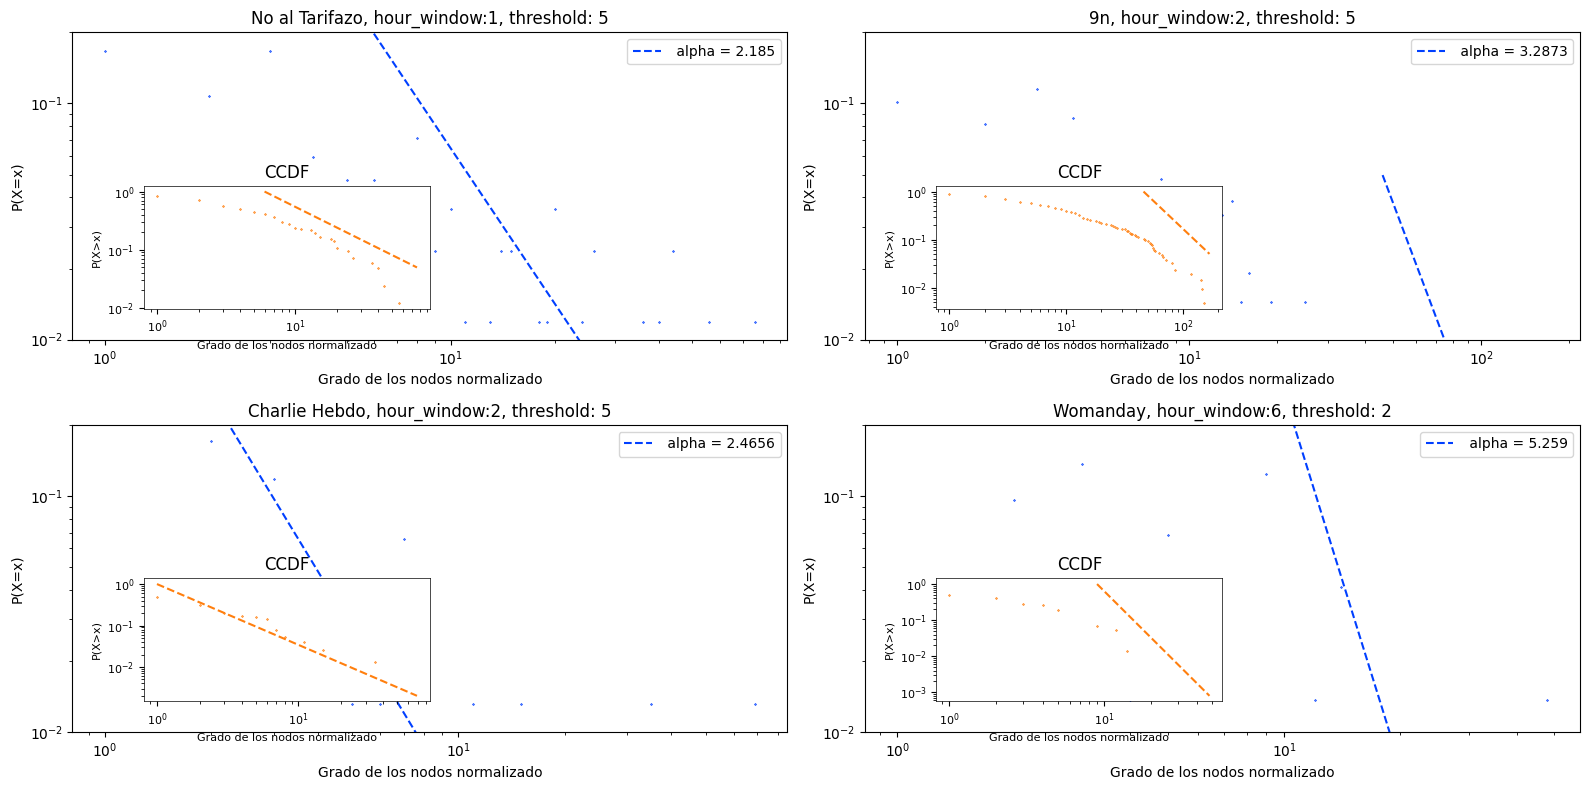

In [22]:
plt.style.use('seaborn-v0_8-bright')    

fig, axs = plt.subplots(2, 2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].scatter(arr_pdf_points_nat[0][0], arr_pdf_points_nat[0][1], marker="x", s=1, alpha=0.7)
plfit_nat.power_law.plot_pdf(label=" alpha = " + str(round(plfit_nat.alpha, 4)), ax=axs[0], linestyle='--')
axs[0].set_ylim(0.01, 0.2)

axs[0].set_xlabel("Grado de los nodos normalizado")
axs[0].set_ylabel("P(X=x)")
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat) + ', threshold: ' + str(umbral_nat))
axs[0].legend()

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_nat = axs[0].inset_axes([0.1, 0.1, 0.4, 0.4])
    ins_ax_nat.set_facecolor('xkcd:white')
    for spine in ins_ax_nat.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ins_ax_nat.set_xscale('log')
    ins_ax_nat.set_yscale('log')

    ins_ax_nat.scatter(arr_ccdf_points_nat[0][0], arr_ccdf_points_nat[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_nat.set_title("CCDF")
    ins_ax_nat.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_nat.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_nat.tick_params(labelsize=8)

    plfit_nat.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_nat.alpha, 5)), ax=ins_ax_nat, linestyle='--', c='#ff7f0e')
    
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].scatter(arr_pdf_points_9n[0][0], arr_pdf_points_9n[0][1], marker="x", s=1, alpha=0.7)
plfit_9n.power_law.plot_pdf(label=" alpha = " + str(round(plfit_9n.alpha, 4)), ax=axs[1], linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
axs[1].legend()
axs[1].set_ylim(0.01, 0.2)

axs[1].set_xlabel("Grado de los nodos normalizado")
axs[1].set_ylabel("P(X=x)")
axs[1].set_title("9n, hour_window:" + str(hour_window_9n) + ', threshold: ' + str(umbral_9n))

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_9n = axs[1].inset_axes([0.1, 0.1, 0.4, 0.4])
    ins_ax_9n.set_facecolor('xkcd:white')
    for spine in ins_ax_9n.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ins_ax_9n.set_xscale('log')
    ins_ax_9n.set_yscale('log')

    ins_ax_9n.scatter(arr_ccdf_points_9n[0][0], arr_ccdf_points_9n[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_9n.set_title("CCDF")
    ins_ax_9n.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_9n.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_9n.tick_params(labelsize=8)

    plfit_9n.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_9n.alpha, 5)), ax=ins_ax_9n, linestyle='--', c='#ff7f0e')


axs[2].set_xscale('log')
axs[2].set_yscale('log')

axs[2].scatter(arr_pdf_points_ch[0][0], arr_pdf_points_ch[0][1], marker="x", s=1, alpha=0.7)
plfit_ch.power_law.plot_pdf(label=" alpha = " + str(round(plfit_ch.alpha, 4)), ax=axs[2], linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
axs[2].legend()
axs[2].set_ylim(0.01, 0.2)

axs[2].set_xlabel("Grado de los nodos normalizado")
axs[2].set_ylabel("P(X=x)")
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch) + ', threshold: ' + str(umbral_ch))

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_ch = axs[2].inset_axes([0.1, 0.1, 0.4, 0.4])
    ins_ax_ch.set_facecolor('xkcd:white')
    for spine in ins_ax_ch.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ins_ax_ch.set_xscale('log')
    ins_ax_ch.set_yscale('log')

    ins_ax_ch.scatter(arr_ccdf_points_ch[0][0], arr_ccdf_points_ch[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_ch.set_title("CCDF")
    ins_ax_ch.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_ch.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_ch.tick_params(labelsize=8)

    plfit_ch.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_ch.alpha, 5)), ax=ins_ax_ch, linestyle='--', c='#ff7f0e')



axs[3].set_xscale('log')
axs[3].set_yscale('log')

axs[3].scatter(arr_pdf_points_wd[0][0], arr_pdf_points_wd[0][1], marker="x", s=1, alpha=0.7)
plfit_wd.power_law.plot_pdf(label=" alpha = " + str(round(plfit_wd.alpha, 4)), ax=axs[3], linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
axs[3].legend()
axs[3].set_ylim(0.01, 0.2)

axs[3].set_xlabel("Grado de los nodos normalizado")
axs[3].set_ylabel("P(X=x)")
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd) + ', threshold: ' + str(umbral_wd))

with plt.style.context('seaborn-v0_8-bright'):
    ins_ax_wd = axs[3].inset_axes([0.1, 0.1, 0.4, 0.4])
    ins_ax_wd.set_facecolor('xkcd:white')
    for spine in ins_ax_wd.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ins_ax_wd.set_xscale('log')
    ins_ax_wd.set_yscale('log')

    ins_ax_wd.scatter(arr_ccdf_points_wd[0][0], arr_ccdf_points_wd[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_wd.set_title("CCDF")
    ins_ax_wd.set_xlabel("Grado de los nodos normalizado", fontsize=8)
    ins_ax_wd.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_wd.tick_params(labelsize=8)

    plfit_wd.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_wd.alpha, 5)), ax=ins_ax_wd, linestyle='--', c='#ff7f0e')



plt.tight_layout()
plt.savefig("plots/PDF-CCDF_f_nat_" + str(hour_window_nat) + "_" + str(umbral_nat) + "_9n_" + str(hour_window_9n) + "_" + str(umbral_9n) + "_ch_" + str(hour_window_ch) + "_" + str(umbral_ch) + "_wd_" + str(hour_window_wd) + "_" + str(umbral_wd) + ".png")
plt.show()

NameError: name 'arr_kt_plot_nat' is not defined

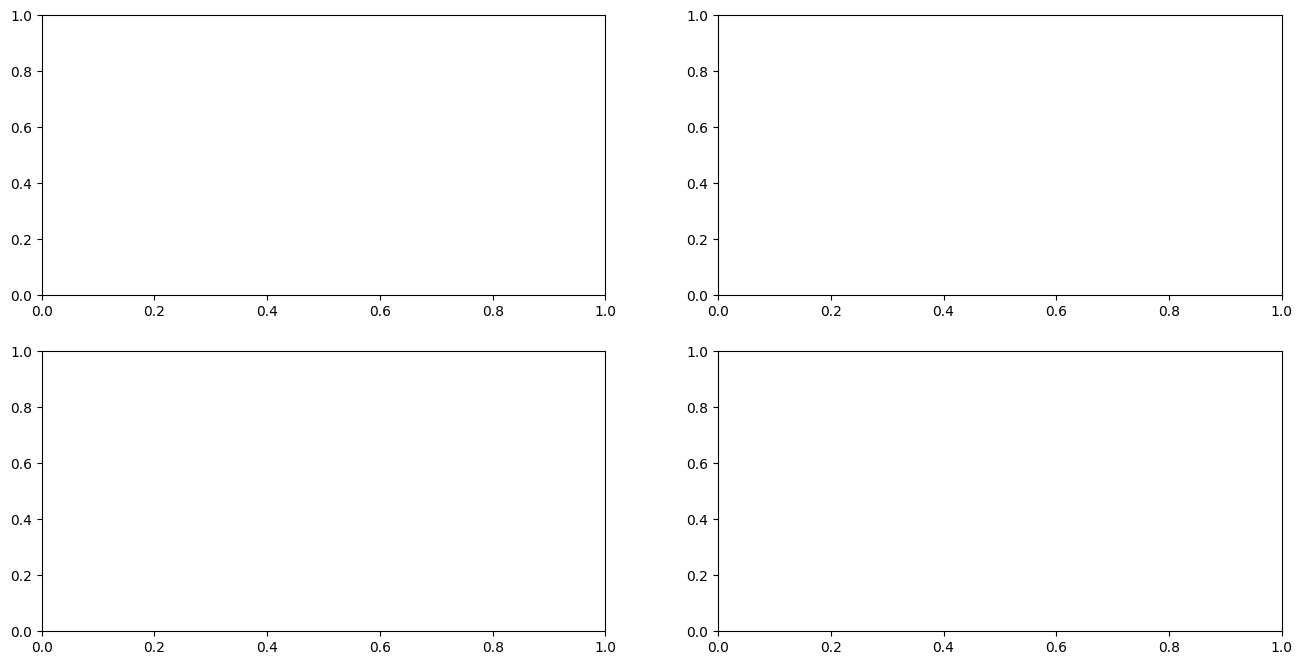

In [23]:
plt.style.use('seaborn-v0_8-bright')    

fig, axs = plt.subplots(2, 2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8)

dot_size=4
marker = "x"
alpha=0.7

for index, points in enumerate(arr_ccdf_points_nat):
    axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_nat[index]))
axs[0].legend()
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(0.02, 1.05)
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))
axs[0].set_xlabel("Grado de los nodos normalizado")
axs[0].set_ylabel("P(X>x)")

for index, points in enumerate(arr_ccdf_points_9n):
    axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_9n[index]))
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(0.02, 1.05)
axs[1].set_title("9n, hour_window:" + str(hour_window_9n))
axs[1].set_xlabel("Grado de los nodos normalizado")
axs[1].set_ylabel("P(X>x)")

for index, points in enumerate(arr_ccdf_points_ch):
    axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_ch[index]))
axs[2].legend()
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_ylim(0.02, 1.05)
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch))
axs[2].set_xlabel("Grado de los nodos normalizado")
axs[2].set_ylabel("P(X>x)")

for index, points in enumerate(arr_ccdf_points_wd):
    axs[3].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_wd[index]))
    # axs[3].plot(points[0], points[1])
axs[3].legend()
axs[3].set_xscale('log')
axs[3].set_yscale('log')
axs[3].set_ylim(0.002, 1.05)
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd))
axs[3].set_xlabel("Grado de los nodos normalizado")
axs[3].set_ylabel("P(X>x)")

plt.tight_layout()
#plt.savefig(plots_folder + "CCDF_Kts_h_nat_" + str(hour_window_nat) + "_9n_" + str(hour_window_9n) + "_ch_" + str(hour_window_ch) +"_wd_" + str(hour_window_wd) + ".png")
plt.show()

### Autosimilitud de redes filtradas

In [86]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat)
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)
dict_thres_avg_clust_wd_h, dict_norm_int_deg_wd_h = calc_self_sim(HORA_CRITICA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/', mode="f", thresh_filter=umbral_wd)

NameError: name 'umbral_nat' is not defined

In [302]:

def scientific_notation(x, pos):
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(x)))
    coeff = x / (10 ** exponent)
    return f"${coeff:.0f} × 10^{{{exponent}}}$"

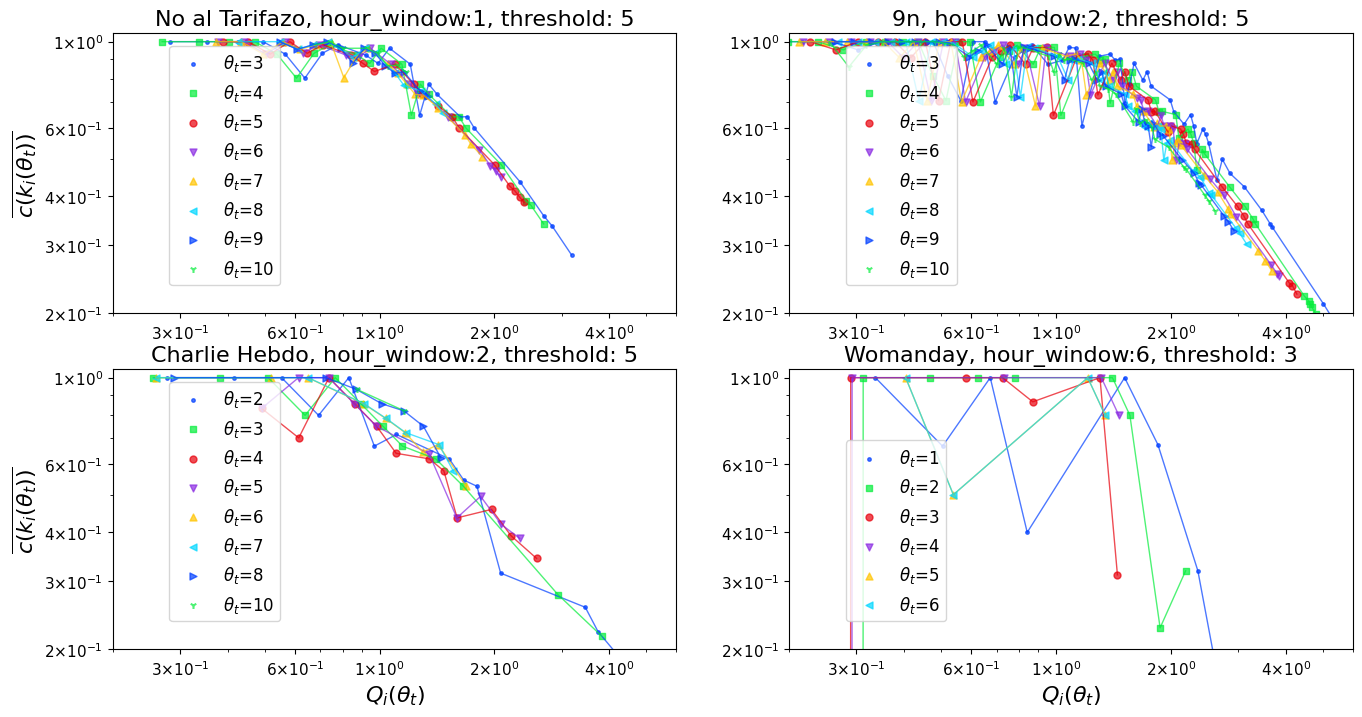

In [303]:

from matplotlib.ticker import FuncFormatter

plt.style.use('seaborn-v0_8-bright')
alpha = 0.7

arr_kt_plot_nat = [3,4,5,6,7,8,9,10]
arr_kt_plot_9n = [3,4,5,6,7,8,9,10]

# Ventana ch 2
arr_kt_plot_ch = [2,3,4,5,6,7,8,10]

# Ventana ch 1
#arr_kt_plot_ch = [1,2,3,4,5,6]

arr_kt_plot_wd = [1,2,3,4,5,6]
# Dado un diccionario con K_t como claves y como valores diccionarios con internal degrees como clave y la media de coeficiente de clusterización
# de los nodos que tienen dicho internal degree como valor, plotea el scatter con la clave en eje X y los valores en eje Y
# Plotea tantos tipos como elementos haya en arr_index(esos indices en concreto)


markers = get_all_markers()

fig, axs = plt.subplots(2, 2)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8) 
for index, kt in enumerate(arr_kt_plot_nat):
    if kt in dict_norm_int_deg_nat_h.keys():
        points_x = list(dict_norm_int_deg_nat_h[kt].keys())
        points_y = list(dict_norm_int_deg_nat_h[kt].values())
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[0].plot(points_x, points_y, alpha=alpha, linewidth=1)
        axs[0].scatter(points_x, points_y, alpha=alpha, s=25, marker=markers[index], label=f'$\\theta_t$={kt}')        

#axs[0].set_xlabel("$Q_i(\\theta_t)$", fontsize=16)
axs[0].set_ylabel("$\\overline{c(k_i(\\theta_t))}$", fontsize=16)
axs[0].set_xscale('log')  
axs[0].set_yscale('log')       
axs[0].set_ylim(0.2, 1.05)
axs[0].set_xlim(0.2, 6)

axs[0].set_xticks([0.3, 0.6, 1, 2, 4])
axs[0].set_yticks([0.2, 0.3, 0.4, 0.6, 1])
formatter = FuncFormatter(scientific_notation)
axs[0].xaxis.set_major_formatter(formatter)
axs[0].yaxis.set_major_formatter(formatter)
axs[0].tick_params(axis='both', which='major', labelsize=11) 

axs[0].legend(loc = (0.1,0.1), fontsize=12)
axs[0].set_title("No al Tarifazo, hour_window:" + str(hour_window_nat) + ', threshold: ' + str(umbral_nat) , fontsize=16)


plt.style.use('seaborn-v0_8-bright')

for index, kt in enumerate(arr_kt_plot_9n):
    if kt in dict_norm_int_deg_9n_h.keys():
        points_x = list(dict_norm_int_deg_9n_h[kt].keys())
        points_y = list(dict_norm_int_deg_9n_h[kt].values())
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[1].plot(points_x, points_y, alpha=alpha, linewidth=1)
        axs[1].scatter(points_x, points_y, alpha=alpha, s=25, marker=markers[index], label=f'$\\theta_t$={kt}')        
        

axs[1].set_ylim(0.2, 1.05)
axs[1].set_xlim(0.2, 6)  

axs[1].set_xscale('log')  
axs[1].set_yscale('log')   


axs[1].set_xticks([0.3, 0.6, 1, 2, 4])
axs[1].set_yticks([0.2, 0.3, 0.4, 0.6, 1])
formatter = FuncFormatter(scientific_notation)
axs[1].xaxis.set_major_formatter(formatter)
axs[1].yaxis.set_major_formatter(formatter)
axs[1].tick_params(axis='both', which='major', labelsize=11)  

#axs[1].set_xlabel("$Q_i(\\theta_t)$", fontsize=16)
#ax2.set_ylabel("$\\overline{c(k_i(\\theta_t))}$")

axs[1].legend(loc = (0.1,0.1), fontsize=12)
axs[1].set_title("9n, hour_window:" + str(hour_window_9n) + ', threshold: ' + str(umbral_9n) , fontsize=16)





plt.style.use('seaborn-v0_8-bright')

for index, kt in enumerate(arr_kt_plot_ch):
    if kt in dict_norm_int_deg_ch_h.keys():
        points_x = list(dict_norm_int_deg_ch_h[kt].keys())
        points_y = list(dict_norm_int_deg_ch_h[kt].values())
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_ch_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[2].plot(points_x, points_y, alpha=alpha, linewidth=1)
        axs[2].scatter(points_x, points_y, alpha=alpha, s=25, marker=markers[index], label=f'$\\theta_t$={kt}')        

axs[2].set_ylim(0.2, 1.05)
axs[2].set_xlim(0.2, 6)  

axs[2].set_xscale('log')  
axs[2].set_yscale('log')   

axs[2].set_xticks([0.3, 0.6, 1, 2, 4])
axs[2].set_yticks([0.2, 0.3, 0.4, 0.6, 1])
formatter = FuncFormatter(scientific_notation)
axs[2].xaxis.set_major_formatter(formatter)
axs[2].yaxis.set_major_formatter(formatter)
axs[2].tick_params(axis='both', which='major', labelsize=11)  

axs[2].set_xlabel("$Q_i(\\theta_t)$", fontsize=16)
axs[2].set_ylabel("$\\overline{c(k_i(\\theta_t))}$", fontsize=16)


axs[2].legend(loc = (0.1,0.1), fontsize=12)
axs[2].set_title("Charlie Hebdo, hour_window:" + str(hour_window_ch) + ', threshold: ' + str(umbral_ch) , fontsize=16)


plt.style.use('seaborn-v0_8-bright')

for index, kt in enumerate(arr_kt_plot_wd):
    if kt in dict_norm_int_deg_wd_h.keys():
        points_x = list(dict_norm_int_deg_wd_h[kt].keys())
        points_y = list(dict_norm_int_deg_wd_h[kt].values())
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_wd_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        axs[3].plot(points_x, points_y, alpha=alpha, linewidth=1)
        axs[3].scatter(points_x, points_y, alpha=alpha, s=25, marker=markers[index], label=f'$\\theta_t$={kt}')        

axs[3].set_ylim(0.2, 1.05)
axs[3].set_xlim(0.2, 6)  

axs[3].set_xscale('log')  
axs[3].set_yscale('log')   

axs[3].set_xticks([0.3, 0.6, 1, 2, 4])
axs[3].set_yticks([0.2, 0.3, 0.4, 0.6, 1])
formatter = FuncFormatter(scientific_notation)
axs[3].xaxis.set_major_formatter(formatter)
axs[3].yaxis.set_major_formatter(formatter)
axs[3].tick_params(axis='both', which='major', labelsize=11)  

axs[3].set_xlabel("$Q_i(\\theta_t)$", fontsize=16)
#ax2.set_ylabel("$\\overline{c(k_i(\\theta_t))}$")

axs[3].legend(loc = (0.1,0.1), fontsize=12)
axs[3].set_title("Womanday, hour_window:" + str(hour_window_wd) + ', threshold: ' + str(umbral_wd) , fontsize=16)

plt.savefig(plots_folder + "self_similarity_f_nat_" + str(hour_window_nat) + "_" + str(umbral_nat) + "_9n_" + str(hour_window_9n) + "_" + str(umbral_9n) + "_ch_" + str(hour_window_ch) + "_" + str(umbral_ch) + "_wd_" + str(hour_window_wd) + "_" + str(umbral_wd) + ".png")
plt.show()

 Ahora hacer 
 
```sudo python3 run_dmercator_docker.py -i ../poster_cs3/github/graphs/filtered/3/ch/2/394718.edge -d 1 -v ../poster_cs3/github/graphs/filtered/3/ch/2/394718.edge```

y, una vez generado los archivos,
ejecutar 

```python3 pdf_d-mercator.py graphs/filtered/3/ch/2/394718.edge```

## Resultados en otras ventanas temporales diferentes a la crítica

In [304]:

# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500

# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
otra_hora_nat = "429600"

# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(otra_hora_nat, MAX_UMBRAL, "nat/")

otra_hora_9n = "437002"
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(otra_hora_9n, MAX_UMBRAL, "9n/")

FileNotFoundError: [Errno 2] No such file or directory: 'graphs/nodes_hashtag/nat/429600.gexf'

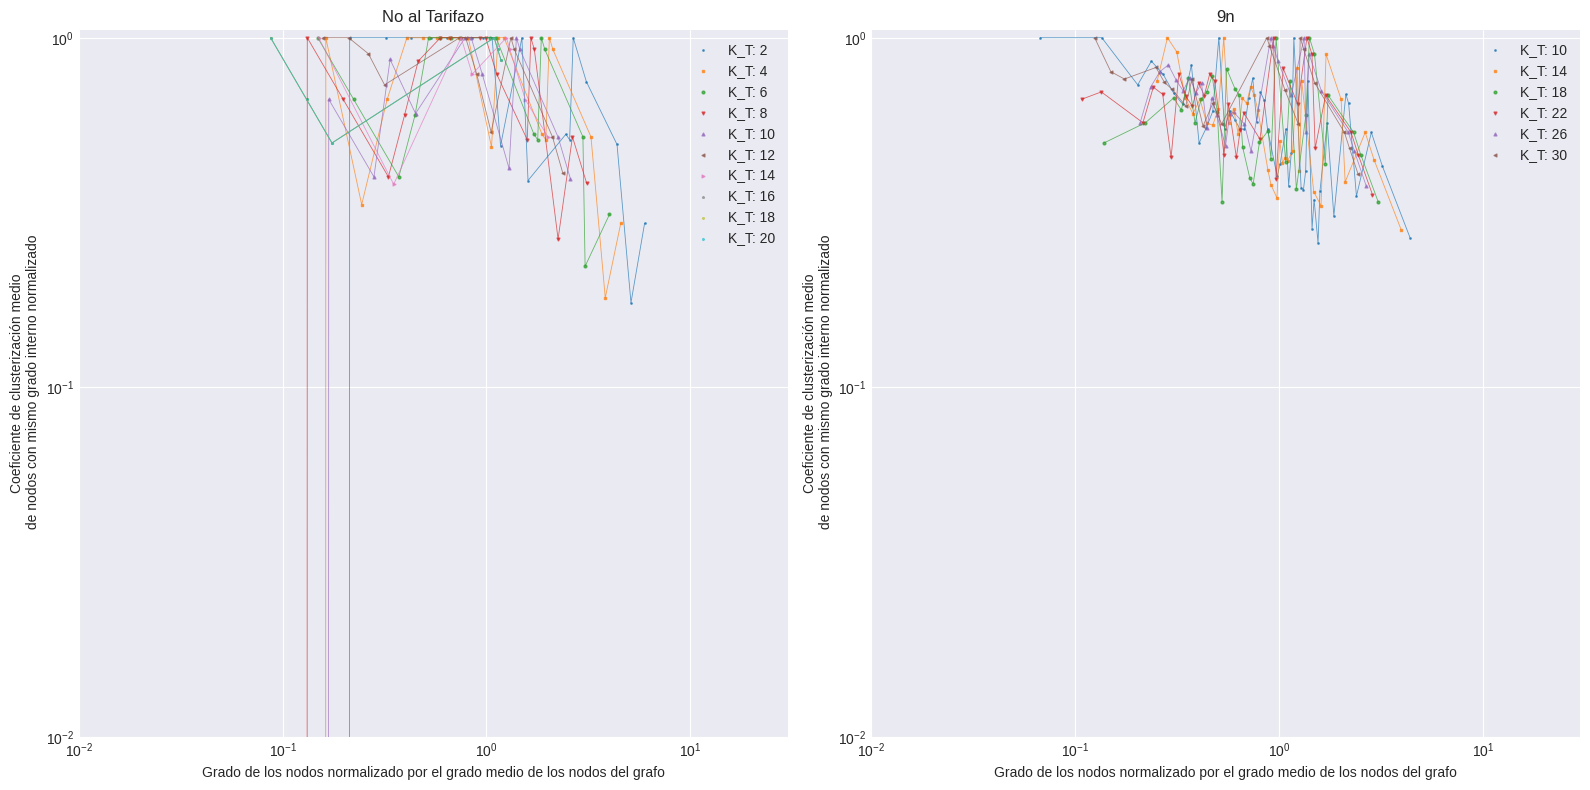

In [ ]:
alpha = 0.7

arr_kt_plot_nat = [2,4,6,8,10,12,14,16,18,20]
arr_kt_plot_9n = [10,14,18,22,26,30]

# Dado un diccionario con K_t como claves y como valores diccionarios con internal degrees como clave y la media de coeficiente de clusterización
# de los nodos que tienen dicho internal degree como valor, plotea el scatter con la clave en eje X y los valores en eje Y
# Plotea tantos tipos como elementos haya en arr_index(esos indices en concreto)


markers = get_all_markers()

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16,8) 

plt.style.use('seaborn-v0_8-darkgrid')

for index, kt in enumerate(arr_kt_plot_nat):
    if kt in dict_norm_int_deg_nat_h.keys():
        points_x = list(dict_norm_int_deg_nat_h[kt].keys())
        points_y = list(dict_norm_int_deg_nat_h[kt].values())
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        ax1.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        ax1.scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

ax1.set_xlabel("Grado de los nodos normalizado por el grado medio de los nodos del grafo")
ax1.set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
ax1.set_xscale('log')  
ax1.set_yscale('log')      
ax1.set_ylim(0.01, 1.05)
ax1.set_xlim(0.01, 30)
ax1.legend()
ax1.set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))

for index, kt in enumerate(arr_kt_plot_9n):
    if kt in dict_norm_int_deg_9n_h.keys():
        points_x = list(dict_norm_int_deg_9n_h[kt].keys())
        points_y = list(dict_norm_int_deg_9n_h[kt].values())
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        ax2.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        ax2.scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

ax2.set_xlabel("Grado de los nodos normalizado por el grado medio de los nodos del grafo")
ax2.set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
ax2.set_xscale('log')  
ax2.set_yscale('log')      
ax2.set_ylim(0.01, 1.05)
ax2.set_xlim(0.01, 30)
ax2.legend()
ax2.set_title("9n, hour_window:" + str(hour_window_9n))

plt.tight_layout()
plt.savefig(plots_folder + "self_similairty_others.png")
plt.show()

# Resultados en redes formadas con diferentes estrategias

## Usuarios como nodos de los grafos

### Ajuste a ley de potencia

In [ ]:
#No al Tarifazo
plfit_nat, arr_pdf_points_nat, arr_ccdf_points_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/", mode="u", graphs_folder=graphs_folder, measures_folder=measures_folder, exp = True, norm=False)

# 9n
plfit_9n, arr_pdf_points_9n, arr_ccdf_points_9n = calc_degree_distribution(HORA_CRITICA_9N, "9n/", mode="u", graphs_folder=graphs_folder, measures_folder=measures_folder, exp = True, norm=False)

100%|██████████| 1/1 [00:00<00:00, 22919.69it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 31068.92it/s]

Calculating best minimal value for power law fit


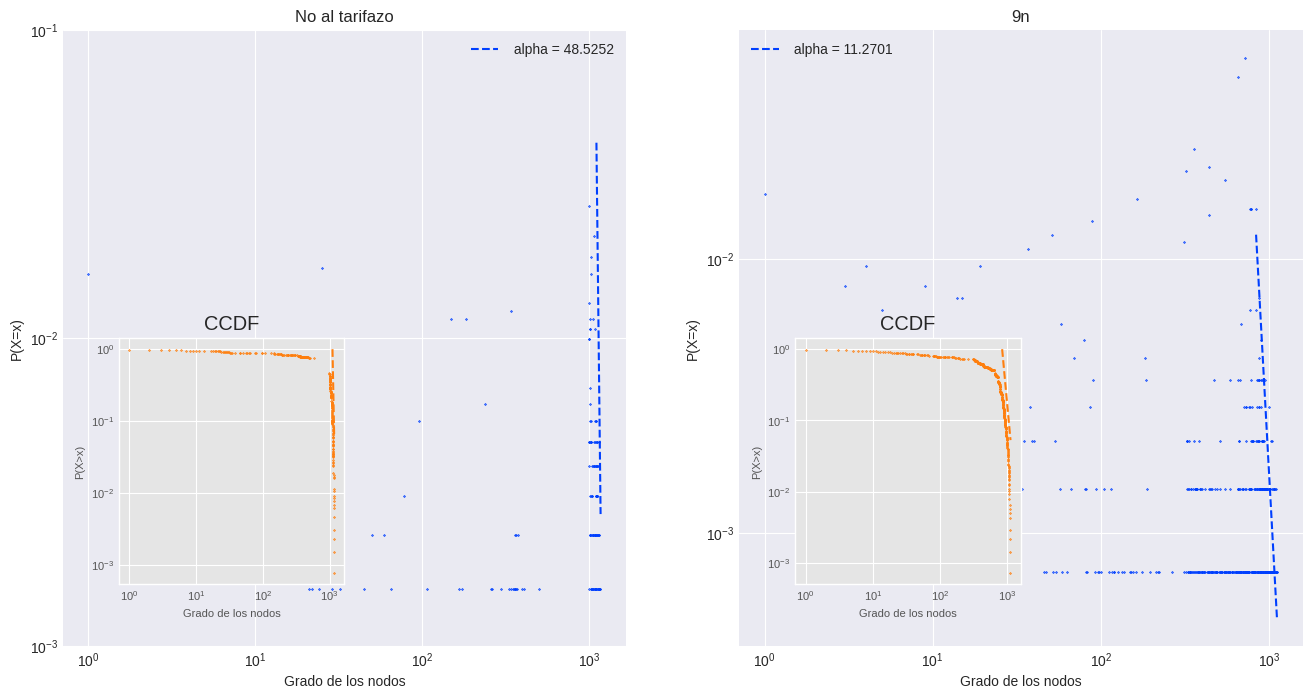

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')    

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16,8)
ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.scatter(arr_pdf_points_nat[0][0], arr_pdf_points_nat[0][1], marker="x", s=1, alpha=0.7)
plfit_nat.power_law.plot_pdf(label=" alpha = " + str(round(plfit_nat.alpha, 4)), ax=ax1, linestyle='--')
ax1.set_ylim(0.001, 0.1)

ax1.set_xlabel("Grado de los nodos")
ax1.set_ylabel("P(X=x)")
ax1.set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))
ax1.legend()

with plt.style.context('ggplot'):
    ins_ax_nat = ax1.inset_axes([0.1, 0.1, 0.4, 0.4])
    ins_ax_nat.set_xscale('log')
    ins_ax_nat.set_yscale('log')

    ins_ax_nat.scatter(arr_ccdf_points_nat[0][0], arr_ccdf_points_nat[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_nat.set_title("CCDF")
    ins_ax_nat.set_xlabel("Grado de los nodos", fontsize=8)
    ins_ax_nat.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_nat.tick_params(labelsize=8)

    plfit_nat.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_nat.alpha, 5)), ax=ins_ax_nat, linestyle='--', c='#ff7f0e')
    
ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.scatter(arr_pdf_points_9n[0][0], arr_pdf_points_9n[0][1], marker="x", s=1, alpha=0.7)
plfit_9n.power_law.plot_pdf(label=" alpha = " + str(round(plfit_9n.alpha, 4)), ax=ax2, linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
ax2.legend()

ax2.set_xlabel("Grado de los nodos")
ax2.set_ylabel("P(X=x)")
ax2.set_title("9n, hour_window:" + str(hour_window_9n))

with plt.style.context('ggplot'):
    ins_ax_9n = ax2.inset_axes([0.1, 0.1, 0.4, 0.4])
    ins_ax_9n.set_xscale('log')
    ins_ax_9n.set_yscale('log')

    ins_ax_9n.scatter(arr_ccdf_points_9n[0][0], arr_ccdf_points_9n[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_9n.set_title("CCDF")
    ins_ax_9n.set_xlabel("Grado de los nodos", fontsize=8)
    ins_ax_9n.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_9n.tick_params(labelsize=8)

    plfit_9n.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_9n.alpha, 5)), ax=ins_ax_9n, linestyle='--', c='#ff7f0e')

plt.tight_layout
plt.savefig("plots/PDF_CCDF_nodes_user.png")
plt.show()

### Autosimilitud

In [40]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 250

# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_u, dict_norm_int_deg_nat_u = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/", mode='u')
dict_thres_avg_clust_9n_u, dict_norm_int_deg_9n_u = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/", mode='u')

100%|██████████| 250/250 [00:36<00:00,  6.82it/s]


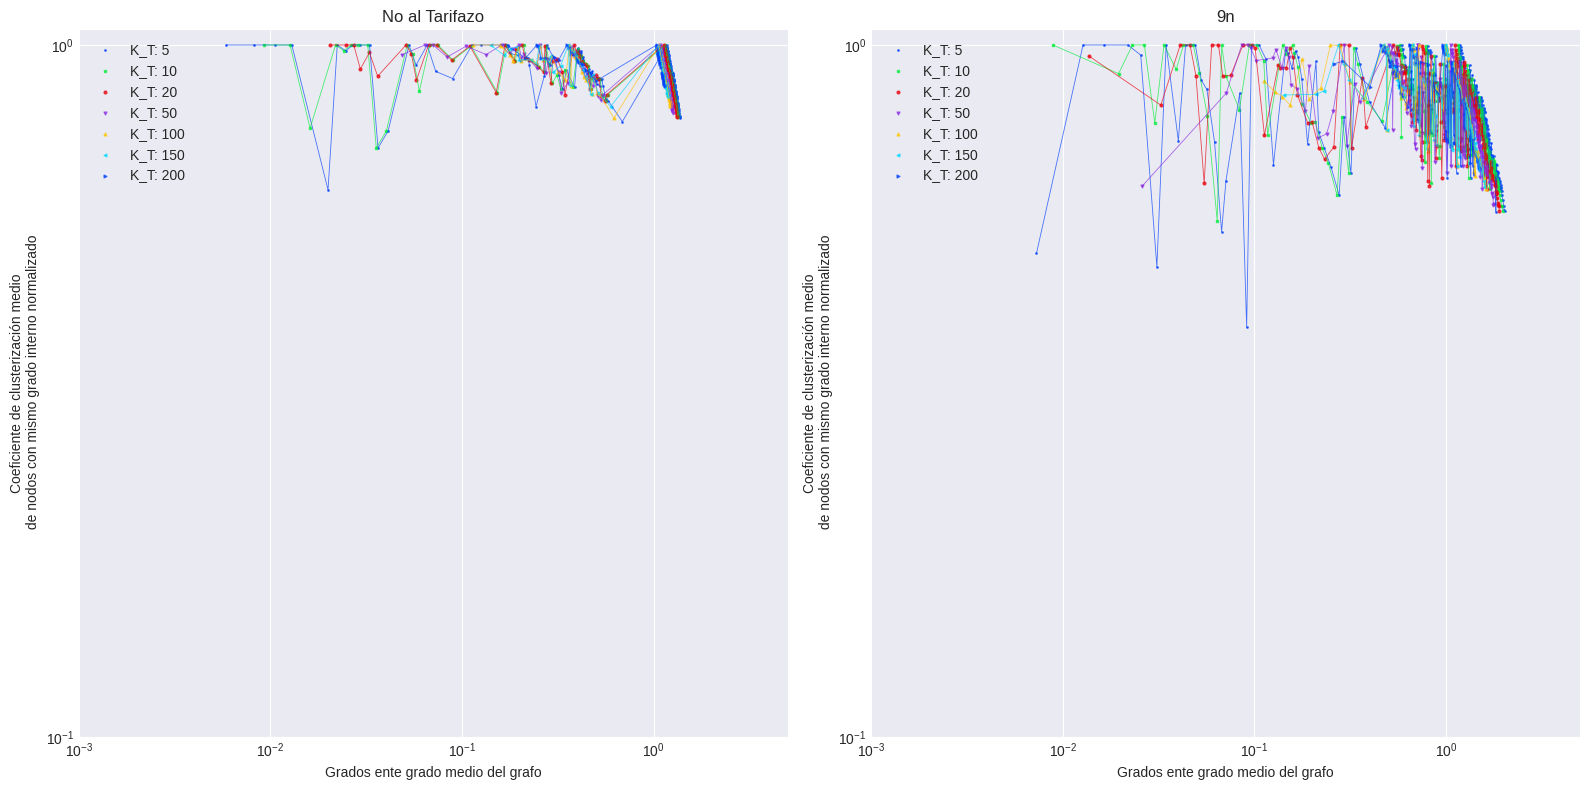

In [41]:
alpha = 0.7

arr_kt_plot_nat = [5,10,20,50,100,150,200,250,300,350]
arr_kt_plot_9n = [5,10,20,50,100,150,200,250,300,350]

# Dado un diccionario con K_t como claves y como valores diccionarios con internal degrees como clave y la media de coeficiente de clusterización
# de los nodos que tienen dicho internal degree como valor, plotea el scatter con la clave en eje X y los valores en eje Y
# Plotea tantos tipos como elementos haya en arr_index(esos indices en concreto)

markers = get_all_markers()

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16,8) 

plt.style.use('seaborn-v0_8-darkgrid')

for index, kt in enumerate(arr_kt_plot_nat):
    if kt in dict_norm_int_deg_nat_u.keys():
        points_x = list(dict_norm_int_deg_nat_u[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_nat_u[kt].values())[::2]
        # Quitamos el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_u[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        ax1.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        ax1.scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

ax1.set_xlabel("Grados ente grado medio del grafo")
ax1.set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
ax1.set_xscale('log')  
ax1.set_yscale('log')      
ax1.set_ylim(0.1, 1.05)
ax1.set_xlim(0.001, 5)
ax1.legend()
ax1.set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))

for index, kt in enumerate(arr_kt_plot_9n):
    if kt in dict_norm_int_deg_9n_u.keys():
        points_x = list(dict_norm_int_deg_9n_u[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_9n_u[kt].values())[::2]
        # Quitamos el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_u[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        ax2.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        ax2.scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

ax2.set_xlabel("Grados ente grado medio del grafo")
ax2.set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
ax2.set_xscale('log')  
ax2.set_yscale('log')      
ax2.set_ylim(0.1, 1.05)
ax2.set_xlim(0.001, 5)
ax2.legend()
ax2.set_title("9n, hour_window:" + str(hour_window_9n))

plt.tight_layout()
plt.savefig(plots_folder + "self_similarity_nodes_user.png")
plt.show()

### Clustering promedio

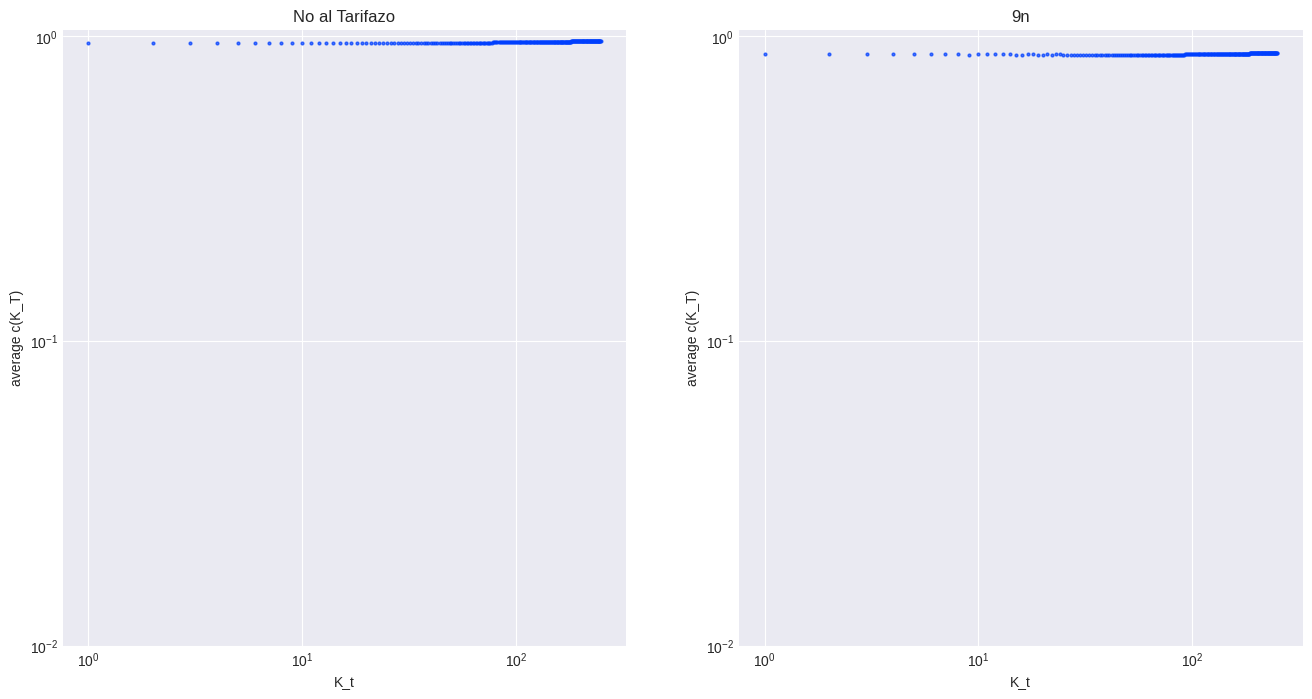

<Figure size 1400x700 with 0 Axes>

In [42]:
alpha = 0.7

arr_kt_plot_nat = [5,10,15,20,25,30,35,40]
arr_kt_plot_9n = [5,10,15,20,25,30,35,40]

markers = get_all_markers()

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16,8) 

plt.styfig = plt.figure(figsize=(14,7)) 
plt.style.use('seaborn-v0_8-darkgrid')

ax1.set_xscale('log')  
ax1.set_yscale('log')      
ax1.set_ylim(0.01, 1.05)     

# Obtener las claves y los valores del diccionario
kt_nat = list(dict_thres_avg_clust_nat_u.keys())[:MAX_UMBRAL]
clust_nat = list(dict_thres_avg_clust_nat_u.values())[:MAX_UMBRAL]

ax1.scatter(kt_nat, clust_nat, s=4, alpha=alpha)

ax1.set_xlabel("K_t")
ax1.set_ylabel("average c(K_T)")
#ax1.legend(["max K_t posible: " + str(int(max(kt_nat)))])
ax1.set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))


ax2.set_xscale('log')  
ax2.set_yscale('log')      
ax2.set_ylim(0.01, 1.05)     


# Obtener las claves y los valores del diccionario
kt_9n = list(dict_thres_avg_clust_9n_u.keys())[:MAX_UMBRAL]
clust_9n = list(dict_thres_avg_clust_9n_u.values())[:MAX_UMBRAL]

ax2.scatter(kt_9n, clust_9n, s=4, alpha=alpha)

ax2.set_xlabel("K_t")
ax2.set_ylabel("average c(K_T)")
#ax2.legend(["max K_t posible: " + str(int(max(kt_9n)))])
ax2.set_title("9n, hour_window:" + str(hour_window_9n))


plt.tight_layout()
plt.savefig(plots_folder + "avg_clust_kt_nodes_user.png")
plt.show()

## Redes bipartitas

### Ajuste a ley de potencia

In [43]:
#No al Tarifazo
plfit_nat, arr_pdf_points_nat, arr_ccdf_points_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/", mode="b", graphs_folder=graphs_folder, measures_folder=measures_folder, exp = True, norm=False)

# 9n
plfit_9n, arr_pdf_points_9n, arr_ccdf_points_9n = calc_degree_distribution(HORA_CRITICA_9N, "9n/", mode="b", graphs_folder=graphs_folder, measures_folder=measures_folder, exp = True, norm=False)

100%|██████████| 1/1 [00:00<00:00, 26379.27it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:00<00:00, 16578.28it/s]

Calculating best minimal value for power law fit


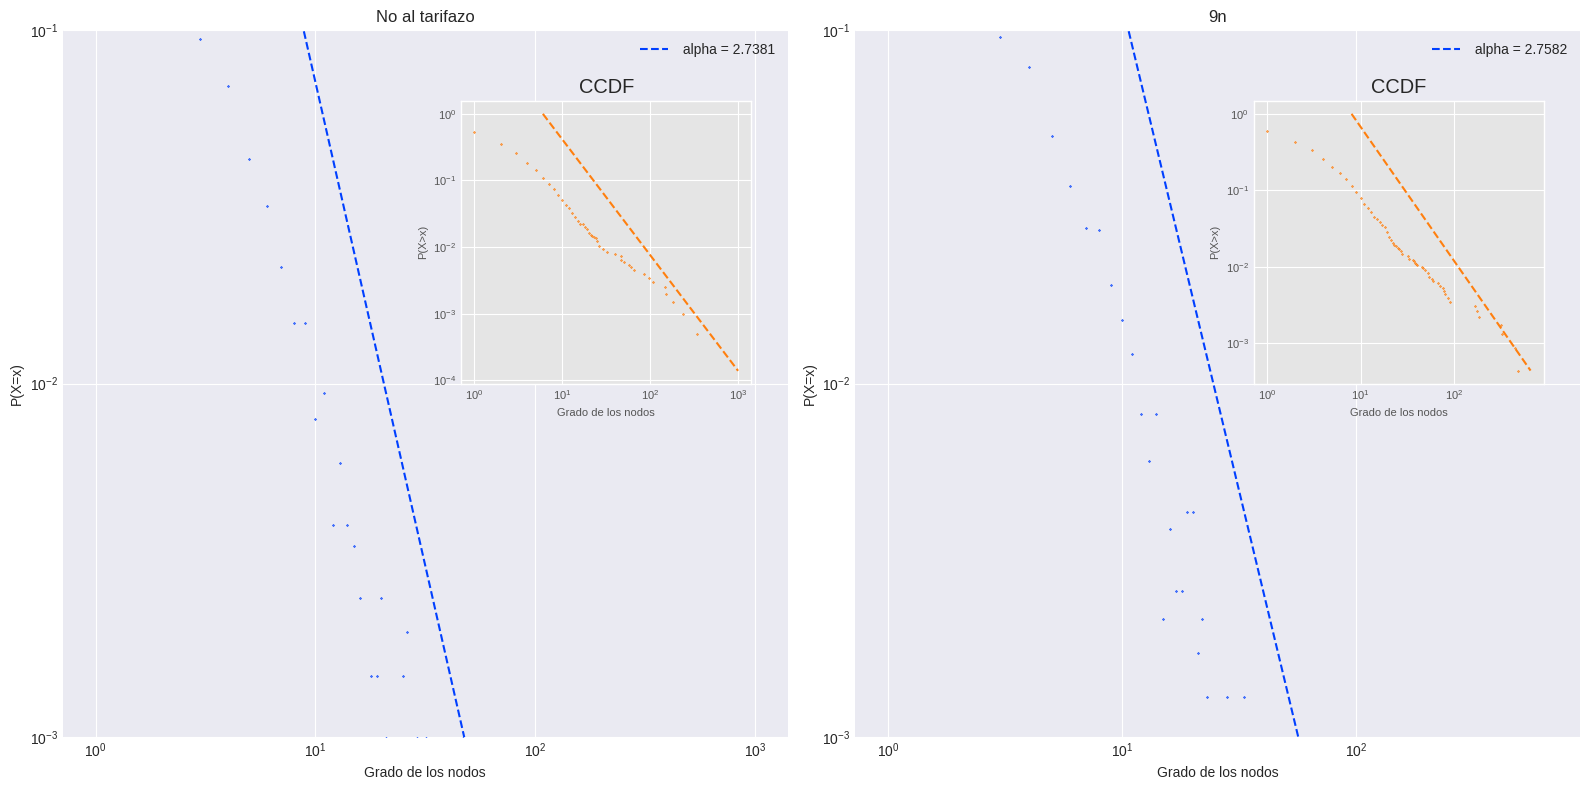

In [44]:
plt.style.use('seaborn-v0_8-darkgrid')    

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16,8)
ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.scatter(arr_pdf_points_nat[0][0], arr_pdf_points_nat[0][1], marker="x", s=1, alpha=0.7)
plfit_nat.power_law.plot_pdf(label=" alpha = " + str(round(plfit_nat.alpha, 4)), ax=ax1, linestyle='--')
ax1.set_ylim(0.001, 0.1)

ax1.set_xlabel("Grado de los nodos")
ax1.set_ylabel("P(X=x)")
ax1.set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))
ax1.legend()

with plt.style.context('ggplot'):
    ins_ax_nat = ax1.inset_axes([0.55, 0.5, 0.4, 0.4])
    ins_ax_nat.set_xscale('log')
    ins_ax_nat.set_yscale('log')

    ins_ax_nat.scatter(arr_ccdf_points_nat[0][0], arr_ccdf_points_nat[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_nat.set_title("CCDF")
    ins_ax_nat.set_xlabel("Grado de los nodos", fontsize=8)
    ins_ax_nat.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_nat.tick_params(labelsize=8)

    plfit_nat.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_nat.alpha, 5)), ax=ins_ax_nat, linestyle='--', c='#ff7f0e')
    

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.scatter(arr_pdf_points_9n[0][0], arr_pdf_points_9n[0][1], marker="x", s=1, alpha=0.7)
plfit_9n.power_law.plot_pdf(label=" alpha = " + str(round(plfit_9n.alpha, 4)), ax=ax2, linestyle='--')
#plfit.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit.alpha, 5)), color='red')
ax2.legend()
ax2.set_ylim(0.001, 0.1)

ax2.set_xlabel("Grado de los nodos")
ax2.set_ylabel("P(X=x)")
ax2.set_title("9n, hour_window:" + str(hour_window_9n))

with plt.style.context('ggplot'):
    ins_ax_9n = ax2.inset_axes([0.55, 0.5, 0.4, 0.4])
    ins_ax_9n.set_xscale('log')
    ins_ax_9n.set_yscale('log')

    ins_ax_9n.scatter(arr_ccdf_points_9n[0][0], arr_ccdf_points_9n[0][1], marker="x", s=1, alpha=0.7, c='#ff7f0e')
    ins_ax_9n.set_title("CCDF")
    ins_ax_9n.set_xlabel("Grado de los nodos", fontsize=8)
    ins_ax_9n.set_ylabel("P(X>x)", fontsize=8)
    ins_ax_9n.tick_params(labelsize=8)

    plfit_9n.power_law.plot_ccdf(label="powerlaw, alpha = " + str(round(plfit_9n.alpha, 5)), ax=ins_ax_9n, linestyle='--', c='#ff7f0e')
    

plt.tight_layout()
plt.savefig("plots/PDF_CCDF_nodes_bipartite.png")
plt.show()

### Autosimilitud

In [45]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 250

# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_b, dict_norm_int_deg_nat_b = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/", mode='b')
dict_thres_avg_clust_9n_b, dict_norm_int_deg_9n_b = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/", mode='b')

 16%|█▌        | 40/250 [00:00<00:00, 588.36it/s]


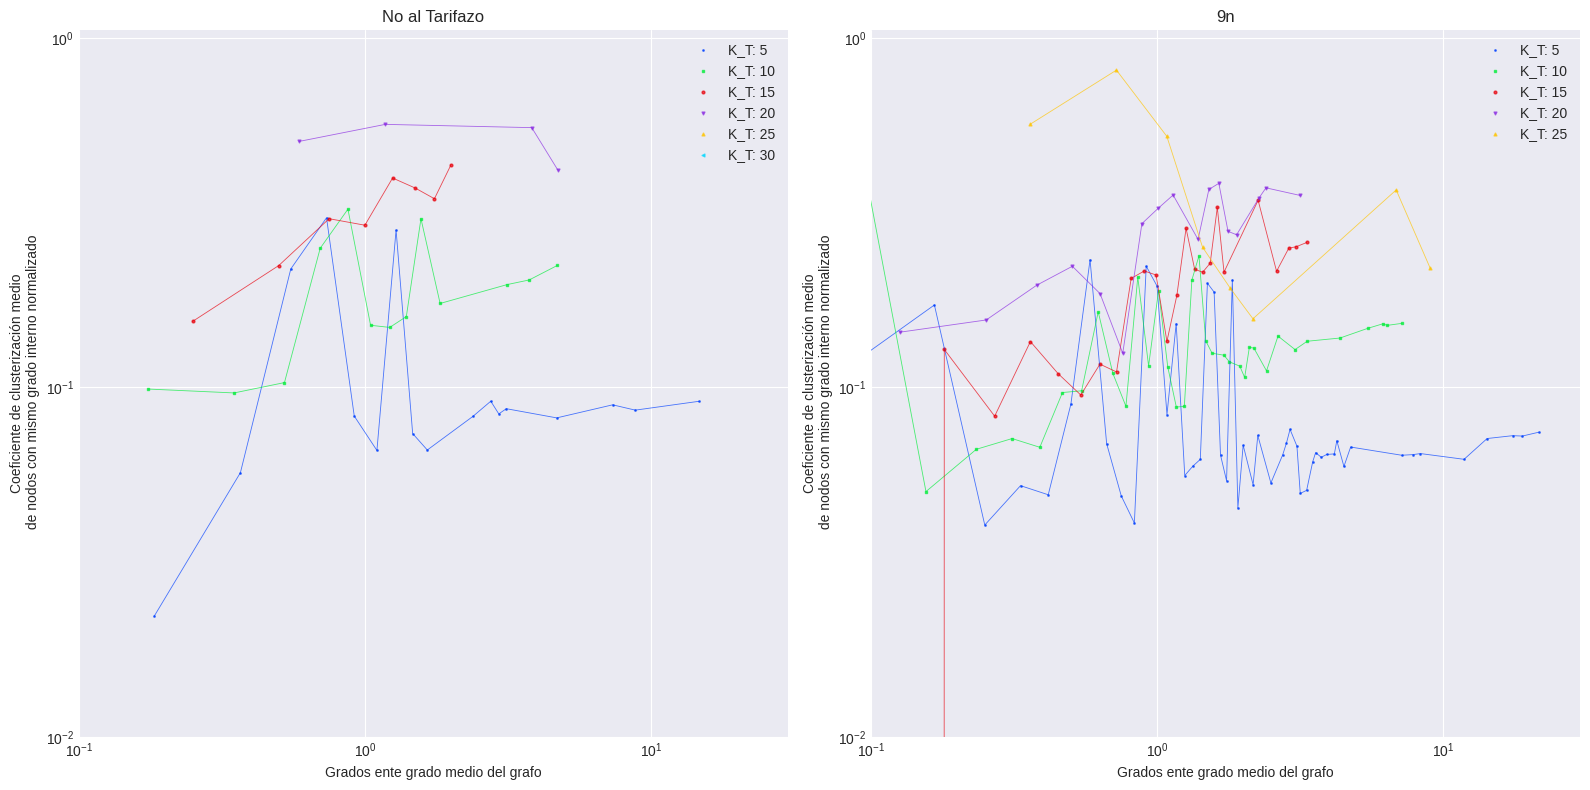

In [46]:
alpha = 0.7
arr_kt_plot_nat = [5,10,15,20,25,30,35,40]
arr_kt_plot_9n = [5,10,15,20,25]

# Dado un diccionario con K_t como claves y como valores diccionarios con internal degrees como clave y la media de coeficiente de clusterización
# de los nodos que tienen dicho internal degree como valor, plotea el scatter con la clave en eje X y los valores en eje Y
# Plotea tantos tipos como elementos haya en arr_index(esos indices en concreto)


markers = get_all_markers()

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16,8) 

plt.style.use('seaborn-v0_8-darkgrid')

for index, kt in enumerate(arr_kt_plot_nat):
    if kt in dict_norm_int_deg_nat_b.keys():
        points_x = list(dict_norm_int_deg_nat_b[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_nat_b[kt].values())[::2]
        # Quitamos el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_b[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        ax1.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        ax1.scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

ax1.set_xlabel("Grados ente grado medio del grafo")
ax1.set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
ax1.set_xscale('log')  
ax1.set_yscale('log')      
ax1.set_ylim(0.01, 1.05)
ax1.set_xlim(0.1, 30)
ax1.legend()
ax1.set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))

for index, kt in enumerate(arr_kt_plot_9n):
    if kt in dict_norm_int_deg_9n_b.keys():
        points_x = list(dict_norm_int_deg_9n_b[kt].keys())
        points_y = list(dict_norm_int_deg_9n_b[kt].values())
        # Quitamos el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_b[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]
        ax2.plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        ax2.scatter(points_x, points_y, alpha=alpha, s=4, marker=markers[index], label=f'K_T: {kt}')        

ax2.set_xlabel("Grados ente grado medio del grafo")
ax2.set_ylabel("Coeficiente de clusterización medio\n de nodos con mismo grado interno normalizado")
ax2.set_xscale('log')  
ax2.set_yscale('log')      
ax2.set_ylim(0.01, 1.05)
ax2.set_xlim(0.1, 30)
ax2.legend()
ax2.set_title("9n, hour_window:" + str(hour_window_9n))

plt.tight_layout()
plt.savefig(plots_folder + "self_similarity_bipartite.png")
plt.show()

### Clustering promedio

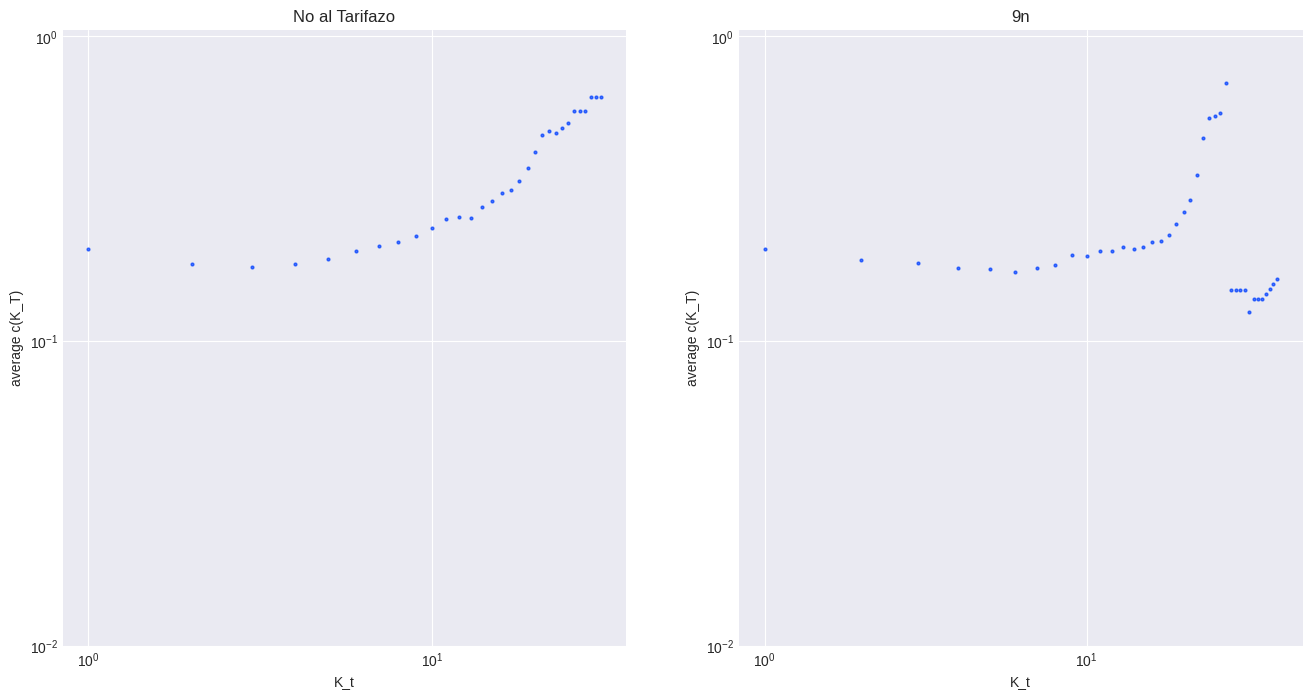

<Figure size 1400x700 with 0 Axes>

In [47]:
alpha = 0.7

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16,8) 

plt.styfig = plt.figure(figsize=(14,7)) 
plt.style.use('seaborn-v0_8-darkgrid')

ax1.set_xscale('log')  
ax1.set_yscale('log')      
ax1.set_ylim(0.01, 1.05)     

# Obtener las claves y los valores del diccionario
kt_nat = list(dict_thres_avg_clust_nat_b.keys())[:MAX_UMBRAL]
clust_nat = list(dict_thres_avg_clust_nat_b.values())[:MAX_UMBRAL]

ax1.scatter(kt_nat, clust_nat, s=4, alpha=alpha)

ax1.set_xlabel("K_t")
ax1.set_ylabel("average c(K_T)")
#ax1.legend(["max K_t posible: " + str(int(max(kt_nat)))])
ax1.set_title("No al Tarifazo, hour_window:" + str(hour_window_nat))


ax2.set_xscale('log')  
ax2.set_yscale('log')      
ax2.set_ylim(0.01, 1.05)     


# Obtener las claves y los valores del diccionario
kt_9n = list(dict_thres_avg_clust_9n_b.keys())[:MAX_UMBRAL]
clust_9n = list(dict_thres_avg_clust_9n_b.values())[:MAX_UMBRAL]

ax2.scatter(kt_9n, clust_9n, s=4, alpha=alpha)

ax2.set_xlabel("K_t")
ax2.set_ylabel("average c(K_T)")
#ax2.legend(["max K_t posible: " + str(int(max(kt_9n)))])
ax2.set_title("9n, hour_window:" + str(hour_window_9n))

plt.tight_layout()
plt.savefig(plots_folder + "avg_clust_kt_bipartite.png")
plt.show()